# CSE440 NLP Project Notebook

Cached preprocessing, reproducible split, and checkpointed training workflow

## Recommended workflow

1. Inspect the raw train/test files and verify shapes, labels, missing values, duplicates, and artifacts.
2. Finish EDA on the training set first, then compare train vs test only at a high level.
3. Build and save three text versions as separate cached files:
   - `none`
   - `extreme`
   - `optimum`
4. Keep the test set untouched until final evaluation.
5. Create one reproducible validation split and save it so every model uses the same split.
6. Cache TF-IDF features, Skip-gram preparation artifacts, and model checkpoints.
7. Run TF-IDF experiments with:
   - one ML model
   - one deep neural network
8. Run Skip-gram experiments with:
   - SimpleRNN
   - GRU
   - LSTM
   - Bidirectional SimpleRNN
   - Bidirectional GRU
   - Bidirectional LSTM
9. Log every tuning run in a results table and save training histories.
10. Reload the best saved checkpoint instead of retraining when you revisit the notebook.
11. Retrain the final selected setup on the full training data only if needed.
12. Evaluate once on the test set and write the report.

## Suggested group workflow

- Person 1: EDA + preprocessing analysis + report figures
- Person 2: TF-IDF + ML + DNN tuning
- Person 3: Skip-gram + sequence model tuning
- Everyone: final comparison table, report writing, and viva preparation


## Optional setup cell

In [1]:
%pip install -q beautifulsoup4 wordcloud gensim nltk tensorflow

Note: you may need to restart the kernel to use updated packages.


## Imports, seeds, and cache folders

In [2]:
import os
import re
import html
import json
import pickle
import random
import warnings
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import tensorflow as tf

from pathlib import Path
from bs4 import BeautifulSoup
from collections import Counter
from IPython.display import display
from wordcloud import WordCloud
from gensim.models import Word2Vec

from scipy.sparse import save_npz, load_npz
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD

from nltk.stem import PorterStemmer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional, SpatialDropout1D

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 300)
pd.set_option("display.max_columns", 100)

nltk.download("punkt")

SEED = 42
TARGET_COLUMN = "News Topic"
RAW_TEXT_COLUMN = "News Headline"
TEXT_COLUMN = "text"

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

BASE_DIR = Path("project_cache")
PREPROCESSED_DIR = BASE_DIR / "preprocessed"
SPLIT_DIR = BASE_DIR / "splits"
TFIDF_DIR = BASE_DIR / "tfidf"
SKIPGRAM_DIR = BASE_DIR / "skipgram"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
HISTORY_DIR = BASE_DIR / "history"
FIGURE_DIR = Path("figures")
LOG_DIR = Path("logs")

for folder in [PREPROCESSED_DIR, SPLIT_DIR, TFIDF_DIR, SKIPGRAM_DIR, CHECKPOINT_DIR, HISTORY_DIR, FIGURE_DIR, LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

FORCE_REBUILD_PREPROCESSED = False
FORCE_NEW_SPLIT = False
FORCE_REBUILD_FEATURES = False
FORCE_REBUILD_SKIPGRAM = False
FORCE_RETRAIN = False

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Cache helpers and training control

This notebook uses one fixed seed for reproducibility and separate cache folders for preprocessing outputs, splits, TF-IDF features, Skip-gram inputs, checkpoints, and training histories.

A seed makes results repeatable. It does not remove the need to train. To avoid rerunning all epochs, the notebook saves model checkpoints and reloads the best saved weights when available.


In [3]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as file:
        pickle.dump(obj, file)

def load_pickle(path):
    with open(path, "rb") as file:
        return pickle.load(file)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as file:
        json.dump(obj, file, indent=2)

def load_json(path):
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)

def safe_name(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text))

def params_signature(params):
    payload = json.dumps(params, sort_keys=True, default=str)
    return hashlib.md5(payload.encode("utf-8")).hexdigest()[:12]

def get_preprocessed_path(split_name, version_name):
    return PREPROCESSED_DIR / f"{split_name}_{version_name}.csv"

def get_split_path(test_size):
    pct = int(round(test_size * 100))
    return SPLIT_DIR / f"group_split_seed{SEED}_val{pct}.csv"

def get_checkpoint_path(run_name):
    return CHECKPOINT_DIR / f"{safe_name(run_name)}.weights.h5"

def get_history_path(run_name):
    return HISTORY_DIR / f"{safe_name(run_name)}_history.json"

def get_done_path(run_name):
    return HISTORY_DIR / f"{safe_name(run_name)}_done.json"

def build_callbacks(run_name, patience=3):
    checkpoint_path = get_checkpoint_path(run_name)
    csv_log_path = HISTORY_DIR / f"{safe_name(run_name)}_training_log.csv"
    return [
        ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(1, patience - 1)),
        CSVLogger(str(csv_log_path), append=True)
    ]

def save_history_object(history, run_name):
    history_dict = history.history if history is not None else {}
    save_json(history_dict, get_history_path(run_name))

def mark_run_complete(run_name, meta=None):
    save_json({"run_name": run_name, "meta": meta or {}}, get_done_path(run_name))

def run_is_complete(run_name):
    return get_checkpoint_path(run_name).exists() and get_done_path(run_name).exists()

## Load the assigned train and test files

In [4]:
TRAIN_PATH = "Training_data_4.csv"
TEST_PATH = "Test_data.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(test_df.shape)
train_df.head()

(104763, 2)
(12000, 2)


,News Headline,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,World News
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",Science and Technology
3,<html> <body> News Headlines:\r\n <br> <b> U.S. Trade Deficit Swells to Record #36;55.5B (AP) AP - America's trade deficit swelled to an all-time high of #36;55.5 billion in October as imports #151; including those from China #151; surged to the loftiest levels on record. Skyrocketing crude-...,Business
4,"<html> <body> News Headlines:\r\n <br> <b> Nonunion firms hit ironworkers with suit Six New England steel-working firms have filed an antitrust lawsuit against one of Boston's most powerful and politically connected unions, alleging that the labor group has conspired to shut out nonunion compani...",Business


## Dataset overview

In [5]:
overview_df = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "missing_text": [train_df["News Headline"].isna().sum(), test_df["News Headline"].isna().sum()],
    "missing_label": [train_df["News Topic"].isna().sum(), test_df["News Topic"].isna().sum()],
    "unique_raw_texts": [train_df["News Headline"].nunique(), test_df["News Headline"].nunique()],
    "duplicate_rows": [train_df.duplicated().sum(), test_df.duplicated().sum()]
})
overview_df

,split,rows,missing_text,missing_label,unique_raw_texts,duplicate_rows
0,train,104763,0,0,73555,31208
1,test,12000,0,0,12000,0


## Class distribution table

In [6]:
train_label_dist = train_df["News Topic"].value_counts().rename("train_count").to_frame()
train_label_dist["train_pct"] = (train_label_dist["train_count"] / len(train_df) * 100).round(2)

test_label_dist = test_df["News Topic"].value_counts().rename("test_count").to_frame()
test_label_dist["test_pct"] = (test_label_dist["test_count"] / len(test_df) * 100).round(2)

label_dist_df = train_label_dist.join(test_label_dist, how="outer")
label_dist_df

,train_count,train_pct,test_count,test_pct
News Topic,,,,
Business,18563,17.72,3000,25.0
Science and Technology,36428,34.77,3000,25.0
Sports,34178,32.62,3000,25.0
World News,15594,14.89,3000,25.0


## Class distribution plot

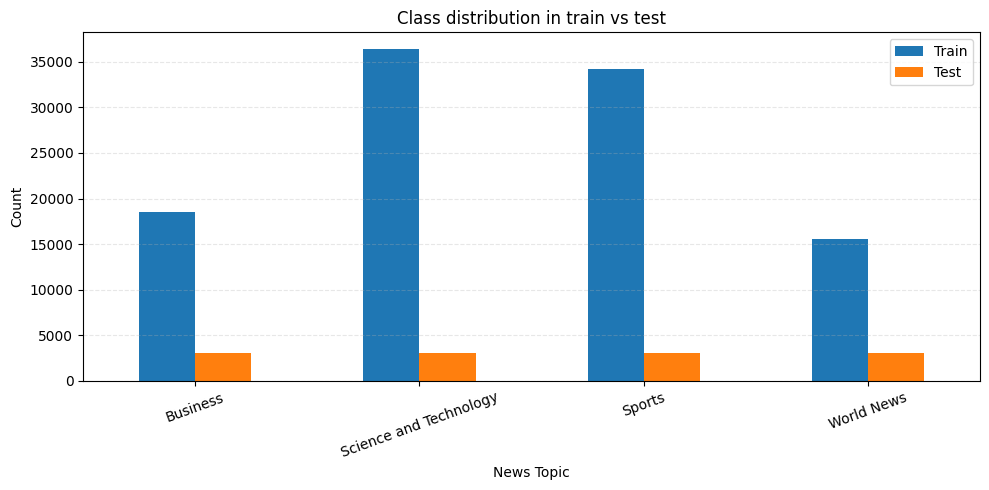

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = pd.DataFrame({
    "Train": train_df["News Topic"].value_counts(),
    "Test": test_df["News Topic"].value_counts()
}).fillna(0)

plot_df.plot(kind="bar", ax=ax)
ax.set_title("Class distribution in train vs test")
ax.set_xlabel("News Topic")
ax.set_ylabel("Count")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Raw sample inspection

In [8]:
sample_view = train_df.sample(5, random_state=SEED)[["News Topic", "News Headline"]]
sample_view

,News Topic,News Headline
7339,Science and Technology,<html> <body> News Headlines:\r\n <br> <b> IBM scores \$1B in Danish contracts IBM announced agreements with two Danish companies on outsourcing deals that together are worth more than \$1 billion over 10 years. </b> \r\n <br> <br>
69095,Science and Technology,"<html> <body> News Headlines:\r\n <br> <b> REVIEW: Kit Automates Holiday Lights (AP) AP - It's a chore that can quickly chill the warmth of the holiday season: Trudging outside each winter night to unplug the lights, deflate the blowup snowman and shut off the rest of the outdoor extravaganza. <..."
73557,Science and Technology,"<html> <body> News Headlines:\r\n <br> <b> Education Helping Seniors Get Online (AP) AP - Wadia Bajoka, a 71-year-old Iraqi immigrant, enjoys knitting, gardening, and baking pungent meat pies that she presents to guests in an old-fashioned display of hospitality. </b> \r\n <br> <br>"
66592,Science and Technology,"<html> <body> News Headlines:\r\n <br> <b> Is there a future for the 1Gig email services? We all remember April 1st when Google announced its new Gmail web-mail service with an overwhelming 1Gig storage space. Their mere announcement brought a new wave of 1Gig web-mail services such as Walla , ..."
35404,World News,"<html> <body> News Headlines:\r\n <br> <b> Electricity Goes Off Across Bahrain (AP) AP - Electricity went out across Bahrain on Monday, leaving people without air conditioning on a day when temperatures were expected to reach 130, snarling rush hour traffic and sending businesses and the U.S. Na..."


## Cleaning helpers for EDA

In [9]:
ENTITY_REPLACEMENTS = {
    r"#39;": "'",
    r"#146;": "'",
    r"quot;": '"',
    r"amp;": "&",
    r"#151;": "-",
    r"#36;": "$",
    r"&lt;": "<",
    r"&gt;": ">"
}

def normalize_artifacts(text):
    text = str(text)
    for pattern, replacement in ENTITY_REPLACEMENTS.items():
        text = re.sub(pattern, replacement, text)
    text = text.replace("\\", " ")
    return text

def basic_eda_clean(text):
    text = normalize_artifacts(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ", strip=True)
    text = html.unescape(text)
    text = re.sub(r"^\s*News Headlines:\s*", "", text, flags=re.I)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, test_df]:
    df["text_eda"] = df["News Headline"].apply(basic_eda_clean)
    df["char_len"] = df["text_eda"].str.len()
    df["word_len"] = df["text_eda"].str.count(r"\b\w+\b")
    df["has_digit"] = df["text_eda"].str.contains(r"\d")
    df["has_parentheses"] = df["text_eda"].str.contains(r"[()]")
    df["has_hyphen"] = df["text_eda"].str.contains(r"-")
    df["has_quote"] = df["text_eda"].str.contains(r"['\"]")
    df["has_backslash"] = df["News Headline"].str.contains(r"\\")
    df["has_html_tags"] = df["News Headline"].str.contains(r"<html>|<body>|<br>|<b>", regex=True)
    df["has_broken_entities"] = df["News Headline"].str.contains(r"#39;|quot;|amp;|#151;|#36;|&lt;|&gt;", regex=True)
    df["starts_with_news_headlines"] = df["News Headline"].str.contains("News Headlines:", regex=False)

train_df[["News Topic", "text_eda"]].head()

,News Topic,text_eda
0,World News,Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region.
1,Science and Technology,"Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday said it had revised its proposal to weed out ""spam"" e-mail to win over skeptical Internet engineers who have been reluctant to adopt technology owned by the dominant software company."
2,Science and Technology,"Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died."
3,Business,U.S. Trade Deficit Swells to Record $55.5B (AP) AP - America's trade deficit swelled to an all-time high of $55.5 billion in October as imports - including those from China - surged to the loftiest levels on record. Skyrocketing crude-oil prices also contributed to the yawning trade gap.
4,Business,"Nonunion firms hit ironworkers with suit Six New England steel-working firms have filed an antitrust lawsuit against one of Boston's most powerful and politically connected unions, alleging that the labor group has conspired to shut out nonunion companies from major construction projects in the ..."


## Data-quality summary

In [10]:
quality_df = pd.DataFrame({
    "metric": [
        "rows",
        "missing_text",
        "missing_label",
        "unique_raw_texts",
        "duplicate_rows",
        "avg_words",
        "median_words",
        "avg_chars",
        "median_chars",
        "has_html_tags_pct",
        "has_broken_entities_pct",
        "has_backslash_pct",
        "starts_with_news_headlines_pct"
    ],
    "train": [
        len(train_df),
        train_df["News Headline"].isna().sum(),
        train_df["News Topic"].isna().sum(),
        train_df["News Headline"].nunique(),
        train_df.duplicated().sum(),
        round(train_df["word_len"].mean(), 2),
        int(train_df["word_len"].median()),
        round(train_df["char_len"].mean(), 2),
        int(train_df["char_len"].median()),
        round(train_df["has_html_tags"].mean() * 100, 2),
        round(train_df["has_broken_entities"].mean() * 100, 2),
        round(train_df["has_backslash"].mean() * 100, 2),
        round(train_df["starts_with_news_headlines"].mean() * 100, 2)
    ],
    "test": [
        len(test_df),
        test_df["News Headline"].isna().sum(),
        test_df["News Topic"].isna().sum(),
        test_df["News Headline"].nunique(),
        test_df.duplicated().sum(),
        round(test_df["word_len"].mean(), 2),
        int(test_df["word_len"].median()),
        round(test_df["char_len"].mean(), 2),
        int(test_df["char_len"].median()),
        round(test_df["has_html_tags"].mean() * 100, 2),
        round(test_df["has_broken_entities"].mean() * 100, 2),
        round(test_df["has_backslash"].mean() * 100, 2),
        round(test_df["starts_with_news_headlines"].mean() * 100, 2)
    ]
})
quality_df

,metric,train,test
0,rows,104763.00,12000.00
1,missing_text,0.00,0.00
2,missing_label,0.00,0.00
3,unique_raw_texts,73555.00,12000.00
4,duplicate_rows,31208.00,0.00
5,avg_words,38.38,38.46
6,median_words,38.00,38.00
7,avg_chars,229.42,230.70
8,median_chars,226.00,229.00
9,has_html_tags_pct,100.00,100.00


## Duplicate analysis

In [11]:
dup_df = train_df.assign(dup_any=train_df["News Headline"].duplicated(keep=False)).groupby("News Topic").agg(
    total=("News Headline", "size"),
    dup_rows=("dup_any", "sum"),
    repeated_beyond_first=("News Headline", lambda s: int(s.duplicated().sum()))
).reset_index()

dup_df["dup_row_pct"] = (dup_df["dup_rows"] / dup_df["total"] * 100).round(2)
dup_df["unique_texts"] = dup_df["total"] - dup_df["repeated_beyond_first"]
dup_df

,News Topic,total,dup_rows,repeated_beyond_first,dup_row_pct,unique_texts
0,Business,18563,0,0,0.00,18563
1,Science and Technology,36428,27010,16424,74.15,20004
2,Sports,34178,24543,14784,71.81,19394
3,World News,15594,0,0,0.00,15594


## Length and class-wise statistics

In [12]:
length_stats_df = train_df.groupby("News Topic").agg(
    count=("text_eda", "size"),
    avg_words=("word_len", "mean"),
    median_words=("word_len", "median"),
    avg_chars=("char_len", "mean"),
    median_chars=("char_len", "median"),
    digits_pct=("has_digit", "mean"),
    parentheses_pct=("has_parentheses", "mean"),
    hyphen_pct=("has_hyphen", "mean"),
    quote_pct=("has_quote", "mean"),
    broken_entities_pct=("has_broken_entities", "mean")
).reset_index()

for col in length_stats_df.columns:
    if col.endswith("_pct"):
        length_stats_df[col] = (length_stats_df[col] * 100).round(2)
    elif col not in ["News Topic", "count"]:
        length_stats_df[col] = length_stats_df[col].round(2)

length_stats_df

,News Topic,count,avg_words,median_words,avg_chars,median_chars,digits_pct,parentheses_pct,hyphen_pct,quote_pct,broken_entities_pct
0,Business,18563,38.29,38.0,230.75,232.0,50.90,36.20,60.22,42.28,38.35
1,Science and Technology,36428,38.05,37.0,231.59,227.0,38.61,28.55,59.73,43.69,28.65
2,Sports,34178,38.36,37.0,221.59,216.0,52.49,25.26,67.10,48.02,35.79
3,World News,15594,39.34,39.0,239.88,240.0,34.27,34.14,63.11,46.10,25.04


## Word-count distribution

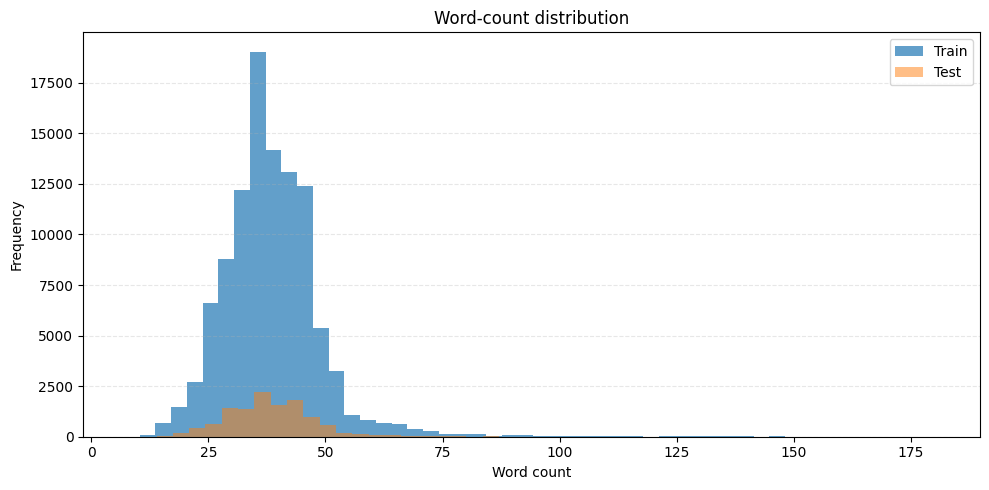

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_df["word_len"], bins=50, alpha=0.7, label="Train")
ax.hist(test_df["word_len"], bins=50, alpha=0.5, label="Test")
ax.set_title("Word-count distribution")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Word-count by class

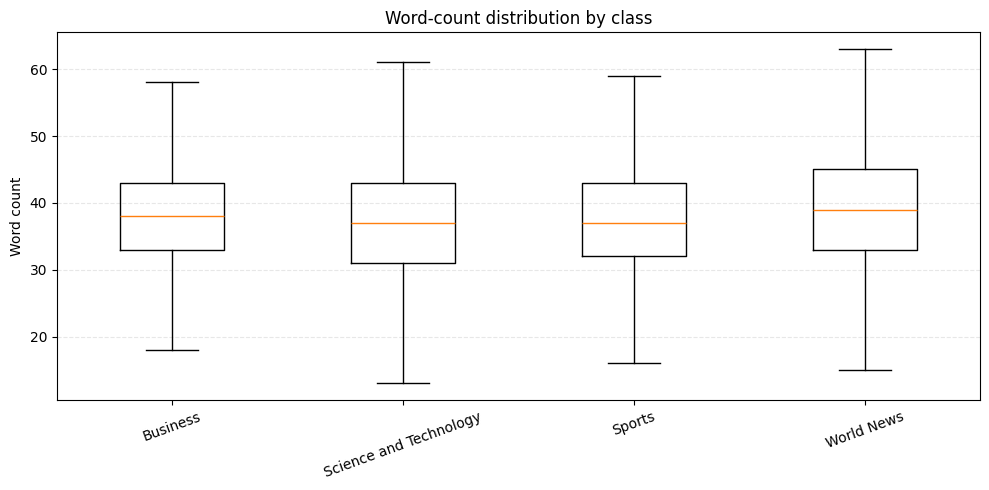

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered_topics = sorted(train_df["News Topic"].unique())
box_data = [train_df.loc[train_df["News Topic"] == topic, "word_len"] for topic in ordered_topics]
ax.boxplot(box_data, labels=ordered_topics, showfliers=False)
ax.set_title("Word-count distribution by class")
ax.set_ylabel("Word count")
plt.xticks(rotation=20)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Source-tag frequency by class

In [15]:
source_df = []
for topic, subset in train_df.groupby("News Topic"):
    source_df.append({
        "News Topic": topic,
        "Reuters_pct": round(subset["text_eda"].str.contains(r"\bReuters\b").mean() * 100, 2),
        "AP_pct": round(subset["text_eda"].str.contains(r"\bAP\b").mean() * 100, 2),
        "AFP_pct": round(subset["text_eda"].str.contains(r"\bAFP\b").mean() * 100, 2)
    })

source_df = pd.DataFrame(source_df)
source_df

,News Topic,Reuters_pct,AP_pct,AFP_pct
0,Business,18.90,0.93,1.09
1,Science and Technology,6.68,6.88,0.68
2,Sports,4.67,10.35,0.51
3,World News,13.10,10.35,6.16


## Most common unigrams after removing source tags

In [16]:
def remove_source_tags(text):
    text = re.sub(r"\((Reuters|AP|AFP)\)", " ", text)
    text = re.sub(r"\b(?:Reuters|AP|AFP)\b\s*[-:)]?", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text_no_source"] = train_df["text_eda"].apply(remove_source_tags)

def get_top_ngrams(texts, ngram_range=(1, 1), top_n=15):
    vectorizer = CountVectorizer(lowercase=True, stop_words="english", ngram_range=ngram_range, min_df=5)
    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    order = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({"term": terms[order], "count": counts[order]})

top_unigrams = {topic: get_top_ngrams(group["text_no_source"], (1, 1), 12) for topic, group in train_df.groupby("News Topic")}
top_bigrams = {topic: get_top_ngrams(group["text_no_source"], (2, 2), 12) for topic, group in train_df.groupby("News Topic")}

top_unigrams["Science and Technology"]

,term,count
0,new,8660
1,microsoft,6231
2,said,4622
3,software,4400
4,internet,4158
5,company,3578
6,space,3262
7,search,2828
8,security,2756
9,web,2649


## Most common bigrams after removing source tags

In [17]:
top_bigrams["Sports"]

,term,count
0,new york,1911
1,red sox,1673
2,sports network,1461
3,world cup,1016
4,united states,637
5,gold medal,625
6,manchester united,619
7,los angeles,578
8,champions league,570
9,ryder cup,566


## Word clouds by class

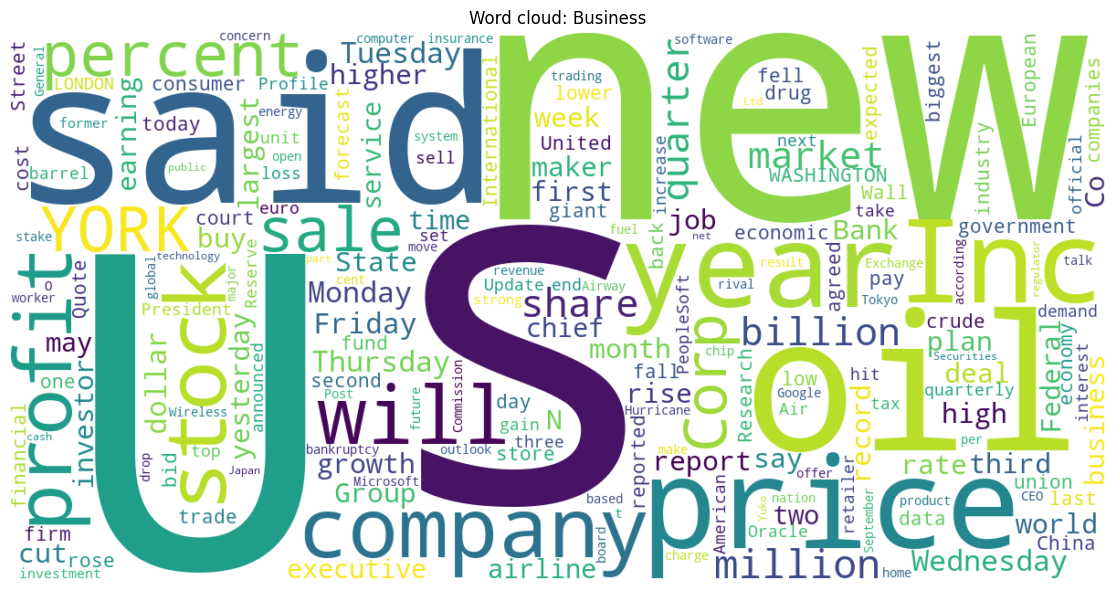

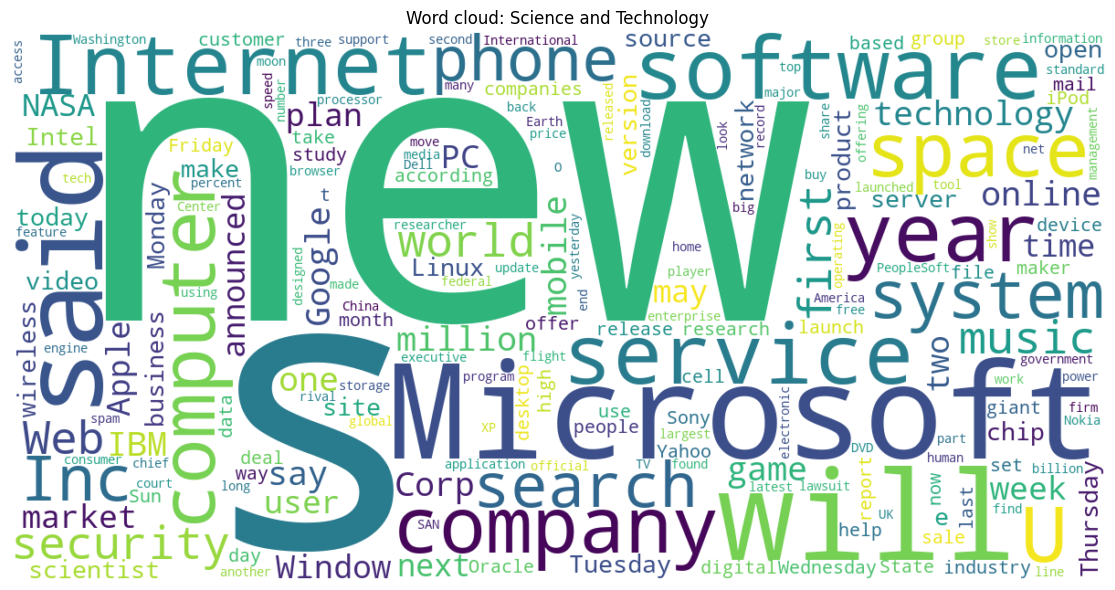

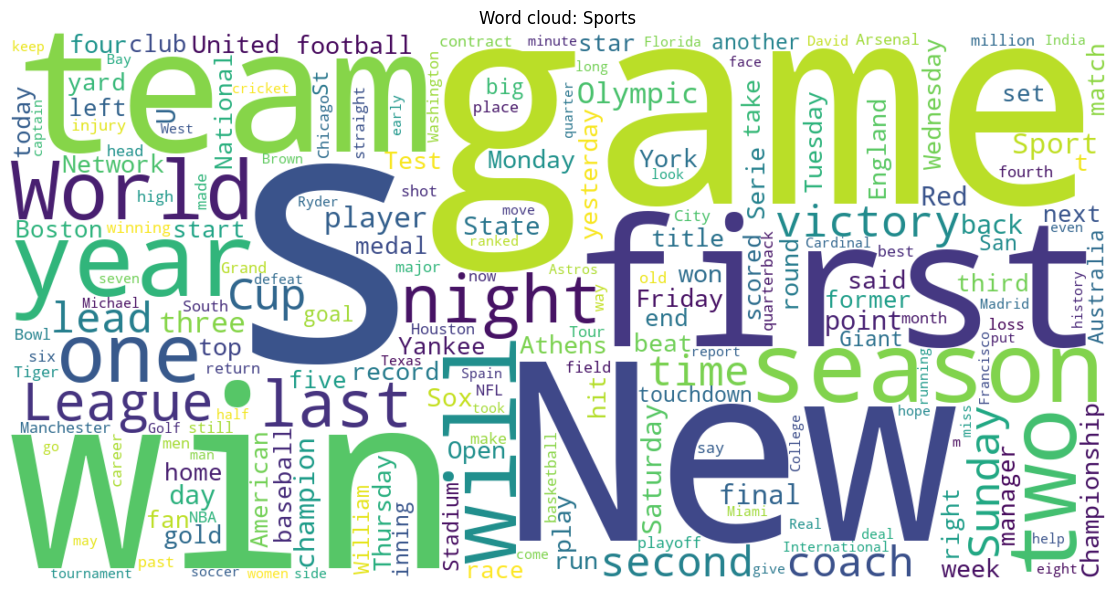

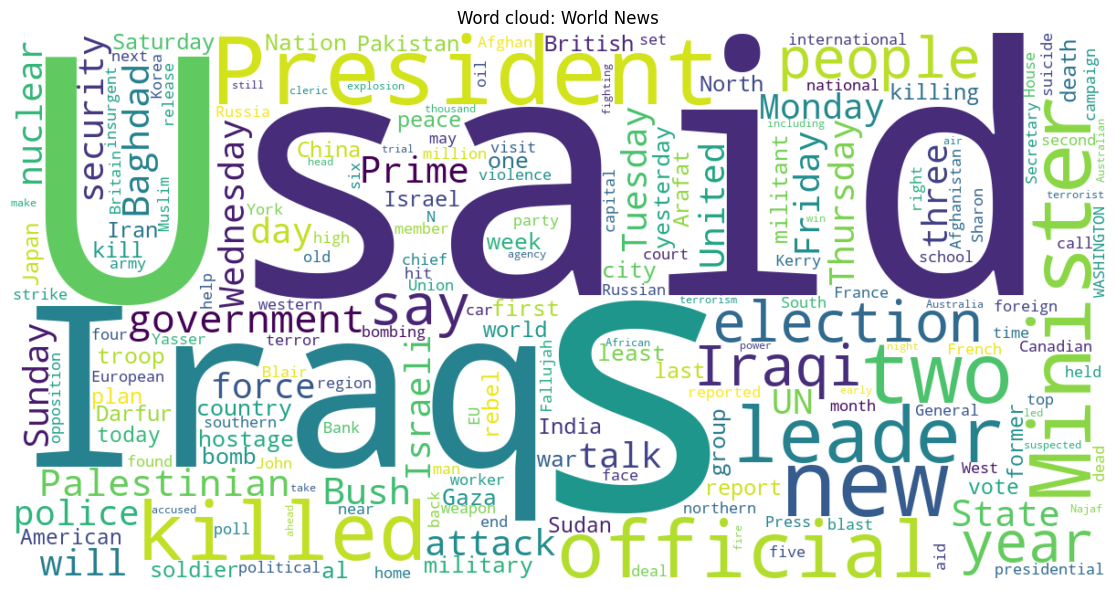

In [18]:
topic_list = sorted(train_df["News Topic"].unique())

for topic in topic_list:
    text_blob = " ".join(train_df.loc[train_df["News Topic"] == topic, "text_no_source"])
    cloud = WordCloud(width=1200, height=600, background_color="white", collocations=False).generate(text_blob)

    plt.figure(figsize=(12, 6))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word cloud: {topic}")
    plt.tight_layout()
    plt.show()

## EDA findings already visible from the dataset

1. The dataset has **104,763 training rows** and **12,000 test rows**, with **4 classes** and **no missing text or label values**.
2. The **training set is imbalanced**:
   - Science and Technology: **34.77%**
   - Sports: **32.62%**
   - Business: **17.72%**
   - World News: **14.89%**
   The **test set is perfectly balanced at 25% per class**, so macro F1 and stratified validation matter a lot.
3. Every row contains **HTML wrappers and the constant prefix `News Headlines:`**. That means HTML stripping is not optional for the preprocessed versions.
4. About **32.16%** of training rows contain broken HTML-style entities such as `#39;`, `quot;`, `amp;`, or `#151;`.
5. About **10.48%** of training rows contain backslash artifacts like `\said` or `\to`.
6. The texts are **not just short headlines**. After basic cleanup, the training texts average about **38.38 words** and **229.42 characters**, which means they behave more like **headline + short news snippet**.
7. The training set has **31,208 exact duplicate rows**, while the test set has **0**. Duplicates are concentrated almost entirely in:
   - Science and Technology: **74.15%** of rows are part of duplicate groups
   - Sports: **71.81%**
   Business and World News have effectively **0% exact duplicate rows**.
8. Digits are common in the text, especially for Sports and Business. Removing numbers in the optimum pipeline is probably a bad idea.
9. Source-wire tags are common and differ by class:
   - Business has strong Reuters presence (**18.90%**)
   - Sports has stronger AP presence (**10.35%**)
   - World News uses a mixture of Reuters, AP, and AFP
   This means source markers may create **publisher-style bias**, so removing them is a good candidate for the optimum preprocessing pipeline.
10. Exact raw train/test overlap is **0**, and overlap after basic cleanup is still very small (**15 texts**), so leakage does not look like the main issue.

## Recommended optimum preprocessing from this EDA

For this dataset, the optimum version should usually:
- remove HTML tags and the `News Headlines:` boilerplate
- normalize broken entities and backslash artifacts
- lowercase the text
- normalize whitespace
- remove source tags like Reuters/AP/AFP
- keep numbers
- keep most stopwords
- avoid stemming

The extreme version can still remove stopwords and apply stemming because the project explicitly asks for it, but the EDA suggests that **extreme preprocessing will probably lose useful meaning** for this dataset.

## Preprocessing design

We will create exactly three text versions:

1. No preprocessing
   - uses the raw text exactly as provided

2. Extreme preprocessing
   - HTML removal
   - broken entity normalization
   - source-tag removal
   - lowercasing
   - non-letter removal
   - stopword removal
   - stemming

3. Optimum preprocessing
   - HTML removal
   - broken entity normalization
   - source-tag removal
   - lowercasing
   - whitespace normalization
   - keeps numbers
   - keeps most stopwords
   - no stemming

The optimum version follows the EDA findings.

## Build, save, and reload the three preprocessing variants

The notebook saves each preprocessing version as a separate CSV for both train and test:
- `train_none.csv` and `test_none.csv`
- `train_extreme.csv` and `test_extreme.csv`
- `train_optimum.csv` and `test_optimum.csv`

Once these files are created, later runs can load them directly instead of preprocessing the raw text again.


In [19]:
STOP_WORDS = set(ENGLISH_STOP_WORDS)
STEMMER = PorterStemmer()

def preprocess_none(text):
    return str(text)

def preprocess_extreme(text):
    text = basic_eda_clean(text)
    text = re.sub(r"\((Reuters|AP|AFP)\)", " ", text)
    text = re.sub(r"\b(?:Reuters|AP|AFP)\b\s*[-:)]?", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z'\s]", " ", text)
    tokens = re.findall(r"[a-z']+", text)
    tokens = [token for token in tokens if token not in STOP_WORDS and len(token) > 1]
    tokens = [STEMMER.stem(token) for token in tokens]
    return " ".join(tokens)

def preprocess_optimum(text):
    text = basic_eda_clean(text)
    text = re.sub(r"\((Reuters|AP|AFP)\)", " ", text)
    text = re.sub(r"\b(?:Reuters|AP|AFP)\b\s*[-:)]?", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9'\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

PREPROCESSORS = {
    "none": preprocess_none,
    "extreme": preprocess_extreme,
    "optimum": preprocess_optimum
}

def build_or_load_preprocessed_frames(source_df, split_name, force=False):
    version_frames = {}
    summary_rows = []

    for version_name, preprocess_fn in PREPROCESSORS.items():
        output_path = get_preprocessed_path(split_name, version_name)

        if output_path.exists() and not force:
            version_df = pd.read_csv(output_path)
            status = "loaded_from_cache"
        else:
            version_df = pd.DataFrame({
                RAW_TEXT_COLUMN: source_df[RAW_TEXT_COLUMN].astype(str),
                TEXT_COLUMN: source_df[RAW_TEXT_COLUMN].astype(str).apply(preprocess_fn)
            })
            if TARGET_COLUMN in source_df.columns:
                version_df[TARGET_COLUMN] = source_df[TARGET_COLUMN].values
                version_df = version_df[[RAW_TEXT_COLUMN, TEXT_COLUMN, TARGET_COLUMN]]
            version_df.to_csv(output_path, index=False)
            status = "built_and_saved"

        version_frames[version_name] = version_df
        summary_rows.append({
            "split": split_name,
            "version": version_name,
            "rows": len(version_df),
            "status": status,
            "path": str(output_path)
        })

    return version_frames, pd.DataFrame(summary_rows)

train_versions_df, train_preprocessed_summary = build_or_load_preprocessed_frames(
    train_df,
    "train",
    force=FORCE_REBUILD_PREPROCESSED
)

test_versions_df, test_preprocessed_summary = build_or_load_preprocessed_frames(
    test_df,
    "test",
    force=FORCE_REBUILD_PREPROCESSED
)

train_versions = {name: frame[TEXT_COLUMN] for name, frame in train_versions_df.items()}
test_versions = {name: frame[TEXT_COLUMN] for name, frame in test_versions_df.items()}

display(pd.concat([train_preprocessed_summary, test_preprocessed_summary], ignore_index=True))

,split,version,rows,status,path
0,train,none,104763,built_and_saved,project_cache\preprocessed\train_none.csv
1,train,extreme,104763,built_and_saved,project_cache\preprocessed\train_extreme.csv
2,train,optimum,104763,built_and_saved,project_cache\preprocessed\train_optimum.csv
3,test,none,12000,built_and_saved,project_cache\preprocessed\test_none.csv
4,test,extreme,12000,built_and_saved,project_cache\preprocessed\test_extreme.csv
5,test,optimum,12000,built_and_saved,project_cache\preprocessed\test_optimum.csv


## Preview the three versions side by side

In [20]:
preview_df = pd.DataFrame({
    "raw": train_df["News Headline"].head(3),
    "no_preprocessing": train_versions["none"].head(3),
    "extreme": train_versions["extreme"].head(3),
    "optimum": train_versions["optimum"].head(3)
})
preview_df

,raw,no_preprocessing,extreme,optimum
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,huge boost darfur aid effort world food programm start airlift ton food day sudan' troubl darfur region,huge boost to darfur aid effort the world food programme is starting to airlift almost 100 more tons of food a day to sudan's troubled darfur region
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...","<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",microsoft revis anti spam standard microsoft corp monday said revis propos weed spam mail win skeptic internet engin reluct adopt technolog own domin softwar compani,microsoft revises anti-spam standard microsoft corp on monday said it had revised its proposal to weed out spam e-mail to win over skeptical internet engineers who have been reluctant to adopt technology owned by the dominant software company
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>","<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",gordon cooper st astronaut ventura calif gordon cooper origin mercuri astronaut pioneer human space explor die,gordon cooper 1 of 1st astronauts ventura calif - gordon cooper who as one of the original mercury astronauts was a pioneer in human space exploration has died


## Optional extra experiment: deduplicate the training set

In [21]:
train_df_dedup = train_df.drop_duplicates(subset=["News Headline"]).copy()
print(train_df.shape)
print(train_df_dedup.shape)

train_versions_dedup = {
    "none": train_df_dedup["News Headline"].apply(preprocess_none),
    "extreme": train_df_dedup["News Headline"].apply(preprocess_extreme),
    "optimum": train_df_dedup["News Headline"].apply(preprocess_optimum)
}

(104763, 14)
(73555, 14)


## One reproducible validation split with duplicate-aware grouping

Because the training data contains many exact duplicates, the split is created at group level using normalized raw text. This prevents the same duplicated headline from appearing in both training and validation.

The split is saved once and reused by every model and preprocessing version.


In [22]:
label_encoder = LabelEncoder()
label_encoder.fit(train_df[TARGET_COLUMN])

def make_group_key(text):
    text = basic_eda_clean(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["group_key"] = train_df[RAW_TEXT_COLUMN].apply(make_group_key)

def build_or_load_group_split(df, test_size=0.15, force=False):
    split_path = get_split_path(test_size)

    if split_path.exists() and not force:
        split_df = pd.read_csv(split_path)
    else:
        group_df = df[[TARGET_COLUMN, "group_key"]].drop_duplicates("group_key").copy()
        train_groups, val_groups = train_test_split(
            group_df["group_key"],
            test_size=test_size,
            random_state=SEED,
            stratify=group_df[TARGET_COLUMN]
        )

        split_df = pd.DataFrame({
            "group_key": list(train_groups) + list(val_groups),
            "split": ["train"] * len(train_groups) + ["val"] * len(val_groups)
        })
        split_df.to_csv(split_path, index=False)

    return split_df

split_map_df = build_or_load_group_split(train_df, test_size=0.15, force=FORCE_NEW_SPLIT)
split_lookup = dict(zip(split_map_df["group_key"], split_map_df["split"]))

def make_split(text_series, label_series, group_keys=None):
    if group_keys is None:
        group_keys = train_df["group_key"]

    split_df = pd.DataFrame({
        TEXT_COLUMN: list(text_series),
        TARGET_COLUMN: list(label_series),
        "group_key": list(group_keys)
    })

    split_df["split"] = split_df["group_key"].map(split_lookup)

    train_part = split_df[split_df["split"] == "train"].copy()
    val_part = split_df[split_df["split"] == "val"].copy()

    X_train = train_part[TEXT_COLUMN].reset_index(drop=True)
    X_val = val_part[TEXT_COLUMN].reset_index(drop=True)
    y_train = train_part[TARGET_COLUMN].reset_index(drop=True)
    y_val = val_part[TARGET_COLUMN].reset_index(drop=True)

    y_train_enc = label_encoder.transform(y_train)
    y_val_enc = label_encoder.transform(y_val)

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_enc),
        y=y_train_enc
    )
    class_weight_dict = {i: class_weights_array[i] for i in range(len(class_weights_array))}
    return X_train, X_val, y_train, y_val, y_train_enc, y_val_enc, class_weight_dict

split_overview = train_df["group_key"].map(split_lookup).value_counts().rename_axis("split").reset_index(name="rows")
display(split_overview)

X_train_opt, X_val_opt, y_train_opt, y_val_opt, y_train_opt_enc, y_val_opt_enc, class_weights_opt = make_split(
    train_versions["optimum"],
    train_df[TARGET_COLUMN],
    train_df["group_key"]
)

print(X_train_opt.shape, X_val_opt.shape)
print(class_weights_opt)

,split,rows
0,train,89158
1,val,15605


(89158,) (15605,)
{0: np.float64(1.4129635499207607), 1: np.float64(0.7170038923022485), 2: np.float64(0.7674919082707803), 3: np.float64(1.6817187264222122)}


## Evaluation helpers

In [23]:
EXPERIMENT_LOG = []

def evaluate_predictions(y_true, y_pred, labels):
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).T
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro")
    }
    return metrics, report_df

def show_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def log_result(preprocessing_name, representation, model_name, split_name, metrics, params):
    EXPERIMENT_LOG.append({
        "preprocessing": preprocessing_name,
        "representation": representation,
        "model": model_name,
        "split": split_name,
        "accuracy": round(metrics["accuracy"], 4),
        "macro_f1": round(metrics["macro_f1"], 4),
        "params": params
    })

## Tuning log helper

In [24]:
TUNING_LOG = []

def log_tuning(stage, preprocessing_name, model_name, params, val_accuracy, val_macro_f1, notes=""):
    TUNING_LOG.append({
        "stage": stage,
        "preprocessing": preprocessing_name,
        "model": model_name,
        "params": str(params),
        "val_accuracy": round(val_accuracy, 4),
        "val_macro_f1": round(val_macro_f1, 4),
        "notes": notes
    })

def tuning_table():
    return pd.DataFrame(TUNING_LOG).sort_values(["stage", "val_macro_f1"], ascending=[True, False])

## TF-IDF feature helper

In [25]:
def build_tfidf_features(preprocessing_name, X_train, X_val, max_features=50000, ngram_range=(1, 2), min_df=3, max_df=0.95):
    params = {
        "max_features": max_features,
        "ngram_range": ngram_range,
        "min_df": min_df,
        "max_df": max_df
    }
    signature = params_signature(params)
    cache_dir = TFIDF_DIR / f"{preprocessing_name}_tfidf_{signature}"
    vectorizer_path = cache_dir / "vectorizer.pkl"
    X_train_path = cache_dir / "X_train_tfidf.npz"
    X_val_path = cache_dir / "X_val_tfidf.npz"

    if vectorizer_path.exists() and X_train_path.exists() and X_val_path.exists() and not FORCE_REBUILD_FEATURES:
        vectorizer = load_pickle(vectorizer_path)
        X_train_tfidf = load_npz(X_train_path)
        X_val_tfidf = load_npz(X_val_path)
    else:
        cache_dir.mkdir(parents=True, exist_ok=True)
        vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            max_df=max_df,
            sublinear_tf=True
        )
        X_train_tfidf = vectorizer.fit_transform(X_train)
        X_val_tfidf = vectorizer.transform(X_val)
        save_pickle(vectorizer, vectorizer_path)
        save_npz(X_train_path, X_train_tfidf)
        save_npz(X_val_path, X_val_tfidf)

    return vectorizer, X_train_tfidf, X_val_tfidf

## TF-IDF with Logistic Regression

In [26]:
def run_logistic_regression(preprocessing_name, train_text, train_labels, class_weight="balanced", C=3.0):
    X_train, X_val, y_train, y_val, y_train_enc, y_val_enc, _ = make_split(train_text, train_labels, train_df["group_key"])
    vectorizer, X_train_tfidf, X_val_tfidf = build_tfidf_features(
        preprocessing_name,
        X_train,
        X_val,
        max_features=40000,
        ngram_range=(1, 2),
        min_df=3
    )

    model = LogisticRegression(
        C=C,
        max_iter=1500,
        class_weight=class_weight
    )
    model.fit(X_train_tfidf, y_train)
    val_pred = model.predict(X_val_tfidf)

    metrics, report_df = evaluate_predictions(y_val, val_pred, label_encoder.classes_)
    log_result(preprocessing_name, "TF-IDF", "LogisticRegression", "validation", metrics, {"C": C, "class_weight": class_weight})
    log_tuning("TF-IDF_ML", preprocessing_name, "LogisticRegression", {"C": C, "class_weight": class_weight}, metrics["accuracy"], metrics["macro_f1"])

    print(metrics)
    display(report_df)
    show_confusion(y_val, val_pred, label_encoder.classes_, f"Logistic Regression | {preprocessing_name}")
    return model, vectorizer, metrics, report_df

## Run Logistic Regression on all three preprocessing variants

Running Logistic Regression for: none
{'accuracy': 0.9214354373598206, 'macro_f1': 0.9099432325012419}


,precision,recall,f1-score,support
Business,0.838456,0.880560,0.858992,2788.000000
Science and Technology,0.936477,0.899831,0.917789,5341.000000
Sports,0.973245,0.977414,0.975325,5136.000000
World News,0.878928,0.896581,0.887667,2340.000000
accuracy,0.921435,0.921435,0.921435,0.921435
macro avg,0.906777,0.913597,0.909943,15605.000000
weighted avg,0.922436,0.921435,0.921704,15605.000000


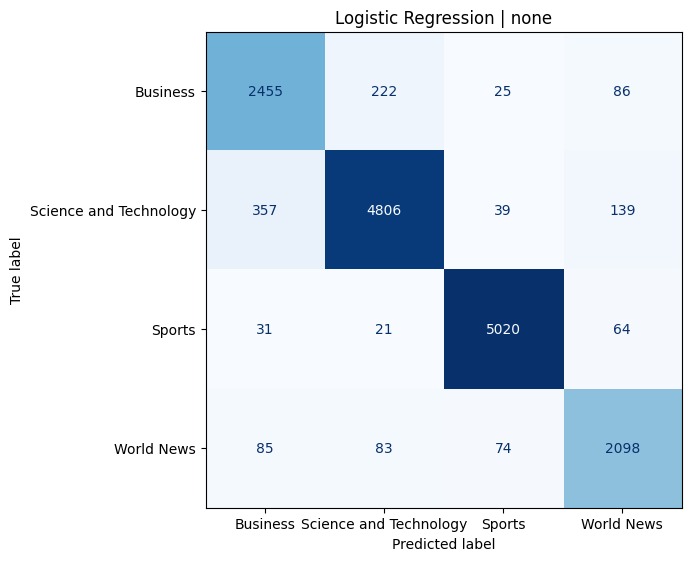

Running Logistic Regression for: extreme
{'accuracy': 0.9151553989106056, 'macro_f1': 0.9029466644467382}


,precision,recall,f1-score,support
Business,0.818060,0.874103,0.845153,2788.000000
Science and Technology,0.934603,0.891032,0.912298,5341.000000
Sports,0.969609,0.975273,0.972433,5136.000000
World News,0.876689,0.887179,0.881903,2340.000000
accuracy,0.915155,0.915155,0.915155,0.915155
macro avg,0.899740,0.906897,0.902947,15605.000000
weighted avg,0.916618,0.915155,0.915536,15605.000000


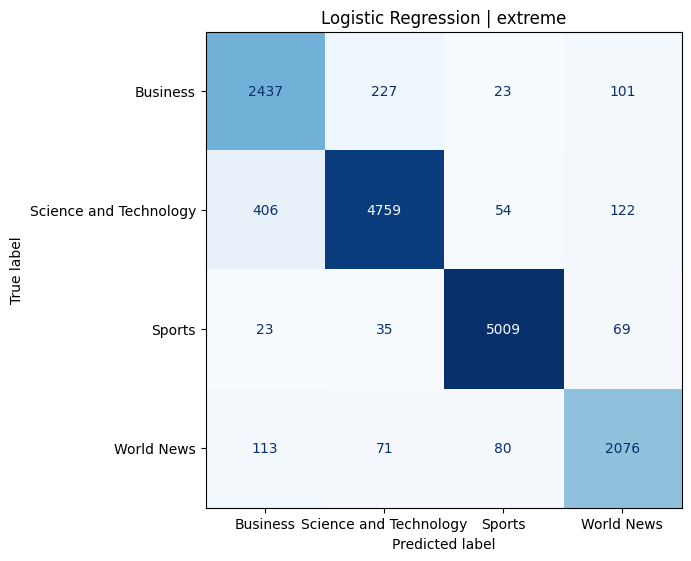

Running Logistic Regression for: optimum
{'accuracy': 0.9154117270105735, 'macro_f1': 0.9032319473426349}


,precision,recall,f1-score,support
Business,0.823589,0.874103,0.848095,2788.000000
Science and Technology,0.929992,0.892904,0.911071,5341.000000
Sports,0.971124,0.975662,0.973388,5136.000000
World News,0.877014,0.883761,0.880375,2340.000000
accuracy,0.915412,0.915412,0.915412,0.915412
macro avg,0.900430,0.906607,0.903232,15605.000000
weighted avg,0.916576,0.915412,0.915727,15605.000000


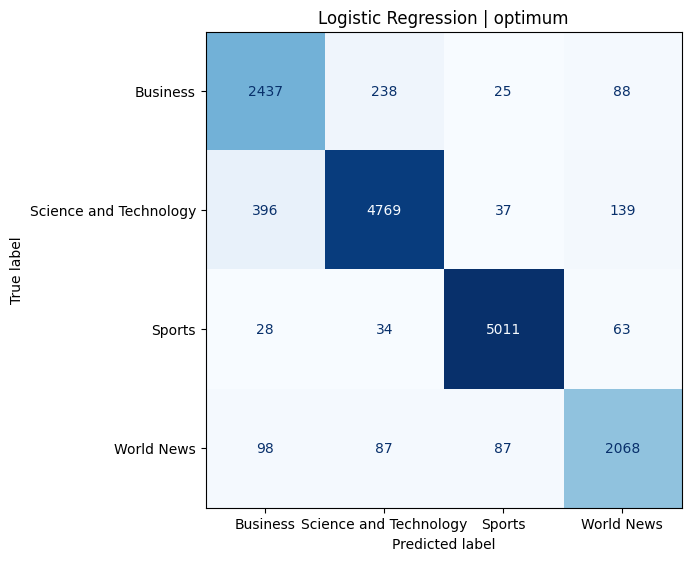

In [27]:
logreg_runs = {}

for preprocessing_name in ["none", "extreme", "optimum"]:
    print("=" * 80)
    print(f"Running Logistic Regression for: {preprocessing_name}")
    logreg_runs[preprocessing_name] = run_logistic_regression(
        preprocessing_name,
        train_versions[preprocessing_name],
        train_df["News Topic"],
        class_weight="balanced",
        C=3.0
    )

## Optional TF-IDF baselines: MultinomialNB and RandomForest

In [28]:
def run_multinomial_nb(preprocessing_name, train_text, train_labels, alpha=0.5):
    X_train, X_val, y_train, y_val, _, _, _ = make_split(train_text, train_labels, train_df["group_key"])
    vectorizer, X_train_tfidf, X_val_tfidf = build_tfidf_features(
        preprocessing_name,
        X_train,
        X_val,
        max_features=40000,
        ngram_range=(1, 2),
        min_df=3
    )

    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_tfidf, y_train)
    val_pred = model.predict(X_val_tfidf)

    metrics, report_df = evaluate_predictions(y_val, val_pred, label_encoder.classes_)
    log_result(preprocessing_name, "TF-IDF", "MultinomialNB", "validation", metrics, {"alpha": alpha})
    log_tuning("TF-IDF_ML", preprocessing_name, "MultinomialNB", {"alpha": alpha}, metrics["accuracy"], metrics["macro_f1"])
    return model, vectorizer, metrics, report_df

def run_random_forest(preprocessing_name, train_text, train_labels, n_estimators=300, max_depth=None):
    X_train, X_val, y_train, y_val, _, _, _ = make_split(train_text, train_labels, train_df["group_key"])
    vectorizer, X_train_tfidf, X_val_tfidf = build_tfidf_features(
        preprocessing_name,
        X_train,
        X_val,
        max_features=20000,
        ngram_range=(1, 2),
        min_df=3
    )

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=SEED,
        n_jobs=-1
    )
    model.fit(X_train_tfidf, y_train)
    val_pred = model.predict(X_val_tfidf)

    metrics, report_df = evaluate_predictions(y_val, val_pred, label_encoder.classes_)
    log_result(preprocessing_name, "TF-IDF", "RandomForest", "validation", metrics, {"n_estimators": n_estimators, "max_depth": max_depth})
    log_tuning("TF-IDF_ML", preprocessing_name, "RandomForest", {"n_estimators": n_estimators, "max_depth": max_depth}, metrics["accuracy"], metrics["macro_f1"])
    return model, vectorizer, metrics, report_df

## TF-IDF + Deep Neural Network

The PDF asks for a DNN with at least 3 to 4+ layers and 128+ neurons in the first layer.

Because raw TF-IDF can be very high-dimensional, two practical options are:

1. use sparse TF-IDF directly as Keras input
2. reduce TF-IDF with TruncatedSVD first, then train the DNN on dense vectors

The cells below implement the safer dense version using TruncatedSVD. It still starts from TF-IDF.

## DNN builder, cached dense inputs, and checkpointed training

In [29]:
def build_tfidf_dnn(input_dim, n_classes, learning_rate=1e-3, dropout_rate=0.3):
    model = Sequential([
        Dense(512, activation="relu", input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(256, activation="relu"),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_or_load_tfidf_dnn_inputs(preprocessing_name, X_train, X_val, n_components=1024):
    tfidf_params = {"max_features": 50000, "ngram_range": (1, 2), "min_df": 3, "max_df": 0.95}
    vectorizer, X_train_tfidf, X_val_tfidf = build_tfidf_features(
        preprocessing_name,
        X_train,
        X_val,
        max_features=tfidf_params["max_features"],
        ngram_range=tfidf_params["ngram_range"],
        min_df=tfidf_params["min_df"],
        max_df=tfidf_params["max_df"]
    )

    params = {"n_components": n_components, **tfidf_params}
    signature = params_signature(params)
    cache_dir = TFIDF_DIR / f"{preprocessing_name}_dnn_{signature}"
    svd_path = cache_dir / "svd.pkl"
    X_train_dense_path = cache_dir / "X_train_dense.npy"
    X_val_dense_path = cache_dir / "X_val_dense.npy"

    if svd_path.exists() and X_train_dense_path.exists() and X_val_dense_path.exists() and not FORCE_REBUILD_FEATURES:
        svd = load_pickle(svd_path)
        X_train_dense = np.load(X_train_dense_path)
        X_val_dense = np.load(X_val_dense_path)
    else:
        cache_dir.mkdir(parents=True, exist_ok=True)
        svd = TruncatedSVD(n_components=n_components, random_state=SEED)
        X_train_dense = svd.fit_transform(X_train_tfidf).astype("float32")
        X_val_dense = svd.transform(X_val_tfidf).astype("float32")
        save_pickle(svd, svd_path)
        np.save(X_train_dense_path, X_train_dense)
        np.save(X_val_dense_path, X_val_dense)

    return vectorizer, svd, X_train_dense, X_val_dense

def run_tfidf_dnn(preprocessing_name, train_text, train_labels, n_components=1024, batch_size=256, epochs=15, force_retrain=False):
    X_train, X_val, y_train, y_val, y_train_enc, y_val_enc, class_weight_dict = make_split(
        train_text,
        train_labels,
        train_df["group_key"]
    )

    vectorizer, svd, X_train_dense, X_val_dense = build_or_load_tfidf_dnn_inputs(
        preprocessing_name,
        X_train,
        X_val,
        n_components=n_components
    )

    run_name = f"TFIDF_DNN_{preprocessing_name}_svd{n_components}_bs{batch_size}_ep{epochs}_seed{SEED}"
    model = build_tfidf_dnn(X_train_dense.shape[1], len(label_encoder.classes_))

    if run_is_complete(run_name) and not (FORCE_RETRAIN or force_retrain):
        model.load_weights(str(get_checkpoint_path(run_name)))
        history = None
        print(f"Loaded saved checkpoint for {run_name}")
    else:
        callbacks = build_callbacks(run_name, patience=3)
        history = model.fit(
            X_train_dense,
            y_train_enc,
            validation_data=(X_val_dense, y_val_enc),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight_dict,
            callbacks=callbacks,
            verbose=1
        )
        save_history_object(history, run_name)
        mark_run_complete(
            run_name,
            {
                "preprocessing": preprocessing_name,
                "representation": "TF-IDF",
                "model": "DeepNN",
                "n_components": n_components,
                "batch_size": batch_size,
                "epochs": epochs
            }
        )

    val_pred = model.predict(X_val_dense, verbose=0).argmax(axis=1)
    val_pred_labels = label_encoder.inverse_transform(val_pred)

    metrics, report_df = evaluate_predictions(y_val, val_pred_labels, label_encoder.classes_)
    log_result(preprocessing_name, "TF-IDF", "DeepNN", "validation", metrics, {"n_components": n_components, "batch_size": batch_size, "epochs": epochs})
    log_tuning("TF-IDF_DNN", preprocessing_name, "DeepNN", {"n_components": n_components, "batch_size": batch_size, "epochs": epochs}, metrics["accuracy"], metrics["macro_f1"])

    print(metrics)
    display(report_df)
    show_confusion(y_val, val_pred_labels, label_encoder.classes_, f"DNN | {preprocessing_name}")
    return model, vectorizer, svd, history, metrics, report_df

## Run the TF-IDF DNN on all three preprocessing variants

Running DNN for: none
Epoch 1/12
343/349 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7447 - loss: 0.7097
Epoch 1: val_loss improved from None to 0.28276, saving model to project_cache\checkpoints\TFIDF_DNN_none_svd1024_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\TFIDF_DNN_none_svd1024_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8556 - loss: 0.4482 - val_accuracy: 0.9029 - val_loss: 0.2828 - learning_rate: 0.0010
Epoch 2/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9185 - loss: 0.2691
Epoch 2: val_loss improved from 0.28276 to 0.27813, saving model to project_cache\checkpoints\TFIDF_DNN_none_svd1024_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\TFIDF_DNN_none_svd1024_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9223 - loss: 0.2579 - val_accuracy: 0.9070 - val_loss: 0.2781 - learning_rate: 0.0010
Epoch 

,precision,recall,f1-score,support
Business,0.784332,0.887016,0.832520,2788.000000
Science and Technology,0.939239,0.859577,0.897644,5341.000000
Sports,0.966866,0.977220,0.972015,5136.000000
World News,0.872735,0.885043,0.878846,2340.000000
accuracy,0.907017,0.907017,0.907017,0.907017
macro avg,0.890793,0.902214,0.895256,15605.000000
weighted avg,0.910684,0.907017,0.907667,15605.000000


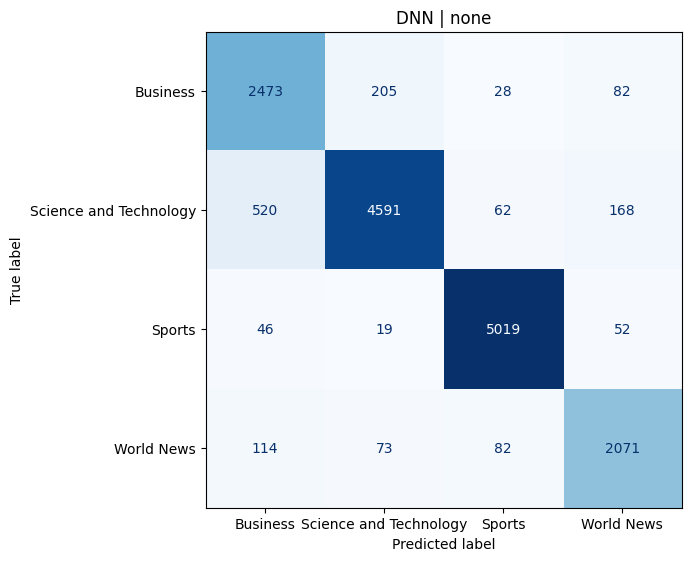

Running DNN for: extreme
Epoch 1/12
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7376 - loss: 0.7099
Epoch 1: val_loss improved from None to 0.28324, saving model to project_cache\checkpoints\TFIDF_DNN_extreme_svd1024_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\TFIDF_DNN_extreme_svd1024_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8520 - loss: 0.4584 - val_accuracy: 0.9075 - val_loss: 0.2832 - learning_rate: 0.0010
Epoch 2/12
344/349 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9192 - loss: 0.2792
Epoch 2: val_loss improved from 0.28324 to 0.27876, saving model to project_cache\checkpoints\TFIDF_DNN_extreme_svd1024_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\TFIDF_DNN_extreme_svd1024_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9228 - loss: 0.2681 - val_accuracy: 0.9100 - val_loss: 0.2788 - learning_rate

,precision,recall,f1-score,support
Business,0.816978,0.862984,0.839351,2788.000000
Science and Technology,0.921626,0.887287,0.904130,5341.000000
Sports,0.960619,0.978388,0.969422,5136.000000
World News,0.887626,0.867521,0.877458,2340.000000
accuracy,0.909965,0.909965,0.909965,0.909965
macro avg,0.896712,0.899045,0.897591,15605.000000
weighted avg,0.910665,0.909965,0.910047,15605.000000


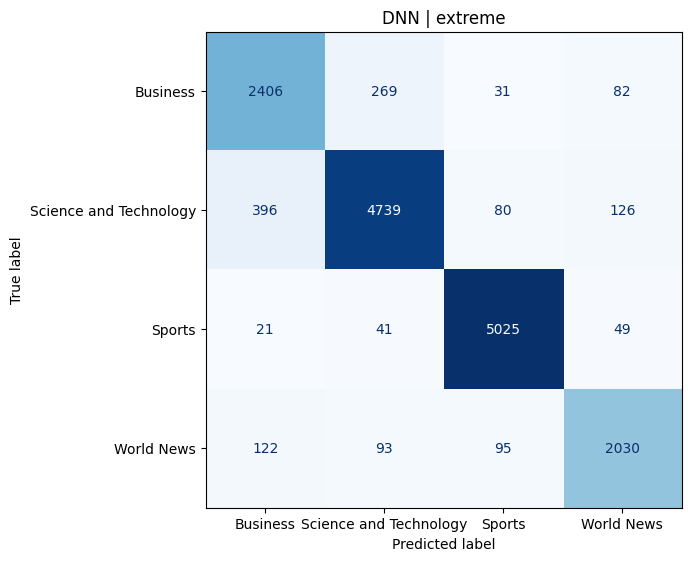

Running DNN for: optimum
Epoch 1/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7445 - loss: 0.7290
Epoch 1: val_loss improved from None to 0.29918, saving model to project_cache\checkpoints\TFIDF_DNN_optimum_svd1024_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\TFIDF_DNN_optimum_svd1024_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8503 - loss: 0.4704 - val_accuracy: 0.9001 - val_loss: 0.2992 - learning_rate: 0.0010
Epoch 2/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9148 - loss: 0.2869
Epoch 2: val_loss improved from 0.29918 to 0.29529, saving model to project_cache\checkpoints\TFIDF_DNN_optimum_svd1024_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\TFIDF_DNN_optimum_svd1024_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9186 - loss: 0.2771 - val_accuracy: 0.9013 - val_loss: 0.2953 - learning_rat

,precision,recall,f1-score,support
Business,0.789285,0.866571,0.826124,2788.000000
Science and Technology,0.924766,0.867628,0.895286,5341.000000
Sports,0.965631,0.968263,0.966945,5136.000000
World News,0.856903,0.872650,0.864705,2340.000000
accuracy,0.901314,0.901314,0.901314,0.901314
macro avg,0.884146,0.893778,0.888265,15605.000000
weighted avg,0.903834,0.901314,0.901929,15605.000000


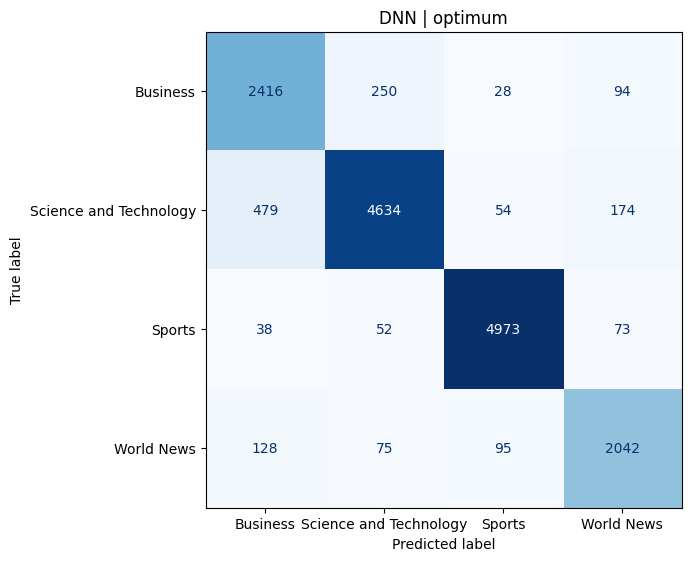

In [30]:
dnn_runs = {}

for preprocessing_name in ["none", "extreme", "optimum"]:
    print("=" * 80)
    print(f"Running DNN for: {preprocessing_name}")
    dnn_runs[preprocessing_name] = run_tfidf_dnn(
        preprocessing_name,
        train_versions[preprocessing_name],
        train_df["News Topic"],
        n_components=1024,
        batch_size=256,
        epochs=12
    )

## Skip-gram preparation

The recurrent models in the PDF should use Skip-gram embeddings.

The workflow below is:
1. tokenize the chosen preprocessed text
2. train Word2Vec with `sg=1`
3. build a tokenizer and padded sequences
4. create the embedding matrix
5. train RNN / GRU / LSTM / bidirectional variants

## Skip-gram helpers and cached sequence preparation

In [31]:
def tokenize_for_skipgram(text_series):
    return [text.split() for text in text_series]

def train_skipgram_embeddings(tokenized_texts, vector_size=200, window=5, min_count=2, epochs=15):
    model = Word2Vec(
        sentences=tokenized_texts,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=1,
        workers=4,
        epochs=epochs,
        seed=SEED
    )
    return model

def build_sequence_data(train_text, val_text, max_vocab=50000, max_len=60):
    tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
    tokenizer.fit_on_texts(train_text)

    X_train_seq = tokenizer.texts_to_sequences(train_text)
    X_val_seq = tokenizer.texts_to_sequences(val_text)

    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
    X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
    return tokenizer, X_train_pad, X_val_pad

def build_embedding_matrix(tokenizer, w2v_model, max_vocab=50000):
    embedding_dim = w2v_model.vector_size
    vocab_size = min(max_vocab, len(tokenizer.word_index) + 1)

    embedding_matrix = np.random.normal(0, 0.05, (vocab_size, embedding_dim))
    embedding_matrix[0] = np.zeros(embedding_dim)

    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]

    return embedding_matrix

## Prepare tokenizer, sequences, and embedding matrix

In [32]:
def prepare_skipgram_inputs(preprocessing_name, train_text_series, train_labels, max_vocab=50000, max_len=60, force=False):
    params = {
        "max_vocab": max_vocab,
        "max_len": max_len,
        "vector_size": 200,
        "window": 5,
        "min_count": 2,
        "w2v_epochs": 15
    }
    signature = params_signature(params)
    cache_dir = SKIPGRAM_DIR / f"{preprocessing_name}_{signature}"
    prepared_path = cache_dir / "prepared.pkl"

    if prepared_path.exists() and not (FORCE_REBUILD_SKIPGRAM or force):
        prepared_data = load_pickle(prepared_path)
        print(f"Loaded cached skip-gram inputs for {preprocessing_name}")
        return prepared_data

    cache_dir.mkdir(parents=True, exist_ok=True)

    X_train, X_val, y_train, y_val, y_train_enc, y_val_enc, class_weight_dict = make_split(
        train_text_series,
        train_labels,
        train_df["group_key"]
    )

    tokenized_train = tokenize_for_skipgram(X_train)
    w2v_model = train_skipgram_embeddings(
        tokenized_train,
        vector_size=params["vector_size"],
        window=params["window"],
        min_count=params["min_count"],
        epochs=params["w2v_epochs"]
    )

    tokenizer, X_train_pad, X_val_pad = build_sequence_data(X_train, X_val, max_vocab=max_vocab, max_len=max_len)
    embedding_matrix = build_embedding_matrix(tokenizer, w2v_model, max_vocab=max_vocab)

    prepared_data = {
        "preprocessing": preprocessing_name,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "y_train_enc": y_train_enc,
        "y_val_enc": y_val_enc,
        "class_weights": class_weight_dict,
        "tokenizer": tokenizer,
        "X_train_pad": X_train_pad,
        "X_val_pad": X_val_pad,
        "embedding_matrix": embedding_matrix,
        "max_vocab": max_vocab,
        "max_len": max_len,
        "params": params
    }

    save_pickle(prepared_data, prepared_path)
    return prepared_data

## Recurrent model builders

In [33]:
def build_simple_rnn_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        SimpleRNN(units),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

def build_gru_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        GRU(units),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

def build_lstm_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        LSTM(units),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

def build_bi_simple_rnn_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        Bidirectional(SimpleRNN(units)),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

def build_bi_gru_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        Bidirectional(GRU(units)),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

def build_bi_lstm_model(vocab_size, embedding_matrix, max_len, n_classes, units=128, dropout_rate=0.3):
    model = Sequential([
        Embedding(vocab_size, embedding_matrix.shape[1], weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(dropout_rate),
        Bidirectional(LSTM(units)),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax")
    ])
    return model

## Unified sequence training with checkpoint reload

In [34]:
def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_sequence_model(prepared_data, model_name, units=128, dropout_rate=0.3, batch_size=256, epochs=12, force_retrain=False):
    embedding_matrix = prepared_data["embedding_matrix"]
    vocab_size = embedding_matrix.shape[0]
    max_len = prepared_data["max_len"]
    n_classes = len(label_encoder.classes_)

    builders = {
        "SimpleRNN": build_simple_rnn_model,
        "GRU": build_gru_model,
        "LSTM": build_lstm_model,
        "BiSimpleRNN": build_bi_simple_rnn_model,
        "BiGRU": build_bi_gru_model,
        "BiLSTM": build_bi_lstm_model
    }

    model = builders[model_name](
        vocab_size=vocab_size,
        embedding_matrix=embedding_matrix,
        max_len=max_len,
        n_classes=n_classes,
        units=units,
        dropout_rate=dropout_rate
    )
    model = compile_model(model)

    run_name = f"SKIPGRAM_{prepared_data['preprocessing']}_{model_name}_u{units}_d{dropout_rate}_bs{batch_size}_ep{epochs}_seed{SEED}"

    if run_is_complete(run_name) and not (FORCE_RETRAIN or force_retrain):
        model.load_weights(str(get_checkpoint_path(run_name)))
        history = None
        print(f"Loaded saved checkpoint for {run_name}")
    else:
        callbacks = build_callbacks(run_name, patience=3)
        history = model.fit(
            prepared_data["X_train_pad"],
            prepared_data["y_train_enc"],
            validation_data=(prepared_data["X_val_pad"], prepared_data["y_val_enc"]),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=prepared_data["class_weights"],
            callbacks=callbacks,
            verbose=1
        )
        save_history_object(history, run_name)
        mark_run_complete(
            run_name,
            {
                "preprocessing": prepared_data["preprocessing"],
                "representation": "Skip-gram",
                "model": model_name,
                "units": units,
                "dropout_rate": dropout_rate,
                "batch_size": batch_size,
                "epochs": epochs
            }
        )

    val_pred = model.predict(prepared_data["X_val_pad"], verbose=0).argmax(axis=1)
    val_pred_labels = label_encoder.inverse_transform(val_pred)
    y_val_labels = prepared_data["y_val"]

    metrics, report_df = evaluate_predictions(y_val_labels, val_pred_labels, label_encoder.classes_)
    log_result(prepared_data["preprocessing"], "Skip-gram", model_name, "validation", metrics, {"units": units, "dropout_rate": dropout_rate, "batch_size": batch_size, "epochs": epochs})
    log_tuning("SKIPGRAM_RNN", prepared_data["preprocessing"], model_name, {"units": units, "dropout_rate": dropout_rate, "batch_size": batch_size, "epochs": epochs}, metrics["accuracy"], metrics["macro_f1"])

    print(metrics)
    display(report_df)
    show_confusion(y_val_labels, val_pred_labels, label_encoder.classes_, f"{model_name} | {prepared_data['preprocessing']}")
    return model, history, metrics, report_df

## Prepare one Skip-gram dataset first

In [35]:
prepared_optimum = prepare_skipgram_inputs(
    "optimum",
    train_versions["optimum"],
    train_df["News Topic"],
    max_vocab=50000,
    max_len=60
)

prepared_optimum.keys()

dict_keys(['preprocessing', 'X_train', 'X_val', 'y_train', 'y_val', 'y_train_enc', 'y_val_enc', 'class_weights', 'tokenizer', 'X_train_pad', 'X_val_pad', 'embedding_matrix', 'max_vocab', 'max_len', 'params'])

## Run the six required sequence models on the optimum preprocessing first

Running SimpleRNN on optimum preprocessing
Epoch 1/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4634 - loss: 1.1613
Epoch 1: val_loss improved from None to 1.38388, saving model to project_cache\checkpoints\SKIPGRAM_optimum_SimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_SimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.4346 - loss: 1.2017 - val_accuracy: 0.3453 - val_loss: 1.3839 - learning_rate: 0.0010
Epoch 2/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2597 - loss: 1.3728
Epoch 2: val_loss improved from 1.38388 to 1.17870, saving model to project_cache\checkpoints\SKIPGRAM_optimum_SimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_SimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.2826 - loss:

,precision,recall,f1-score,support
Business,0.000000,0.000000,0.000000,2788.000000
Science and Technology,0.181818,0.000374,0.000747,5341.000000
Sports,0.381314,0.978972,0.548848,5136.000000
World News,0.741480,0.762393,0.751791,2340.000000
accuracy,0.436655,0.436655,0.436655,0.436655
macro avg,0.326153,0.435435,0.325347,15605.000000
weighted avg,0.298916,0.436655,0.293628,15605.000000


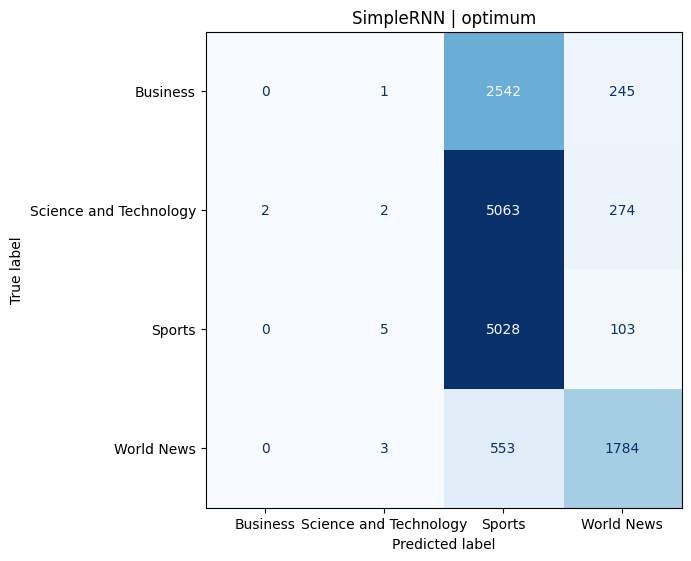

Running GRU on optimum preprocessing
Epoch 1/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.4736 - loss: 1.0632
Epoch 1: val_loss improved from None to 0.29571, saving model to project_cache\checkpoints\SKIPGRAM_optimum_GRU_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_GRU_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 69s 191ms/step - accuracy: 0.6826 - loss: 0.7342 - val_accuracy: 0.9030 - val_loss: 0.2957 - learning_rate: 0.0010
Epoch 2/12
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8908 - loss: 0.3600
Epoch 2: val_loss improved from 0.29571 to 0.27449, saving model to project_cache\checkpoints\SKIPGRAM_optimum_GRU_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_GRU_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 57s 164ms/step - accuracy: 0.8949 - loss: 0.3481 - val_accuracy: 0.

,precision,recall,f1-score,support
Business,0.839045,0.869440,0.853972,2788.000000
Science and Technology,0.931691,0.906572,0.918960,5341.000000
Sports,0.977145,0.982282,0.979707,5136.000000
World News,0.888370,0.894444,0.891397,2340.000000
accuracy,0.923037,0.923037,0.923037,0.923037
macro avg,0.909063,0.913185,0.911009,15605.000000
weighted avg,0.923603,0.923037,0.923209,15605.000000


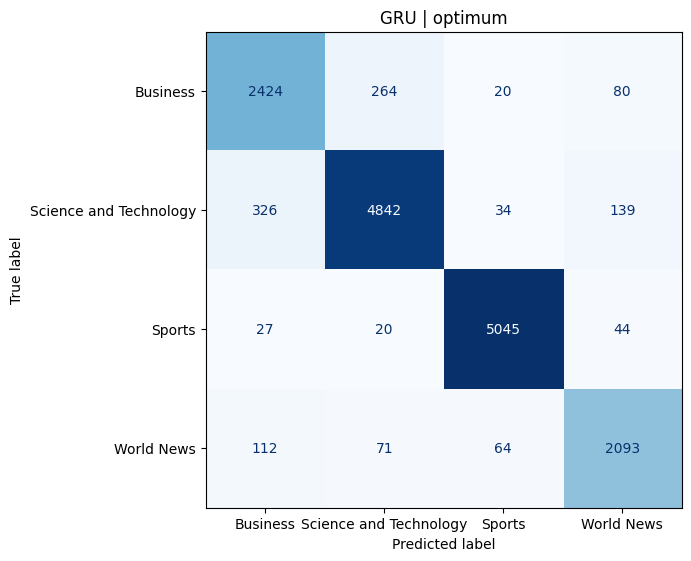

Running LSTM on optimum preprocessing
Epoch 1/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7290 - loss: 0.7099
Epoch 1: val_loss improved from None to 0.28641, saving model to project_cache\checkpoints\SKIPGRAM_optimum_LSTM_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_LSTM_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 73s 205ms/step - accuracy: 0.8301 - loss: 0.5120 - val_accuracy: 0.9043 - val_loss: 0.2864 - learning_rate: 0.0010
Epoch 2/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.8844 - loss: 0.3765
Epoch 2: val_loss improved from 0.28641 to 0.26596, saving model to project_cache\checkpoints\SKIPGRAM_optimum_LSTM_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_LSTM_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.8872 - loss: 0.3667 - val_accurac

,precision,recall,f1-score,support
Business,0.816572,0.876614,0.845528,2788.000000
Science and Technology,0.939611,0.885602,0.911807,5341.000000
Sports,0.977087,0.979751,0.978417,5136.000000
World News,0.865733,0.898291,0.881711,2340.000000
accuracy,0.916886,0.916886,0.916886,0.916886
macro avg,0.899751,0.910064,0.904366,15605.000000
weighted avg,0.918885,0.916886,0.917376,15605.000000


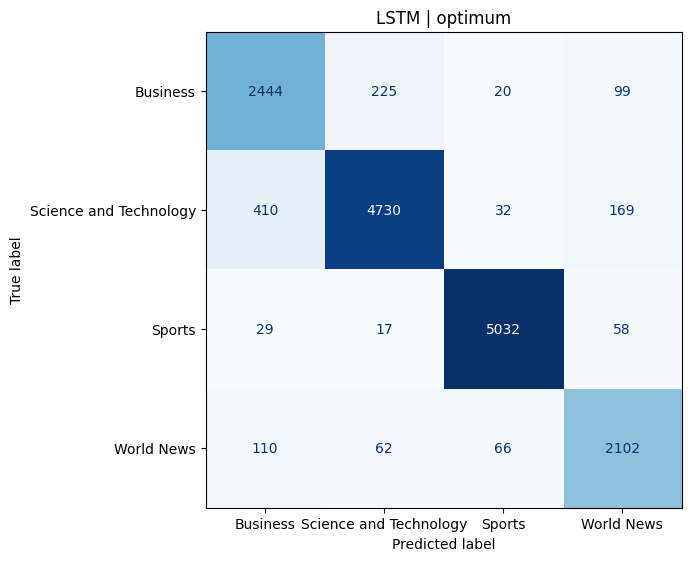

Running BiSimpleRNN on optimum preprocessing
Epoch 1/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7417 - loss: 0.6963
Epoch 1: val_loss improved from None to 0.36994, saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiSimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiSimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.8221 - loss: 0.5407 - val_accuracy: 0.8807 - val_loss: 0.3699 - learning_rate: 0.0010
Epoch 2/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8628 - loss: 0.4454
Epoch 2: val_loss improved from 0.36994 to 0.31789, saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiSimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiSimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.86

,precision,recall,f1-score,support
Business,0.805641,0.850430,0.827430,2788.000000
Science and Technology,0.915771,0.877364,0.896156,5341.000000
Sports,0.971245,0.973326,0.972284,5136.000000
World News,0.855713,0.876923,0.866188,2340.000000
accuracy,0.904069,0.904069,0.904069,0.904069
macro avg,0.887092,0.894511,0.890515,15605.000000
weighted avg,0.905347,0.904069,0.904439,15605.000000


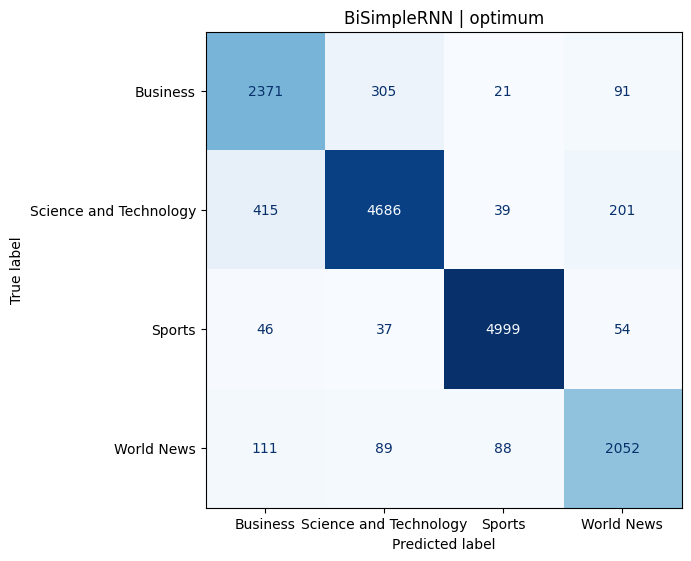

Running BiGRU on optimum preprocessing
Epoch 1/12
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.7807 - loss: 0.6107
Epoch 1: val_loss improved from None to 0.27552, saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiGRU_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiGRU_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 78s 214ms/step - accuracy: 0.8553 - loss: 0.4424 - val_accuracy: 0.9037 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 2/12
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8946 - loss: 0.3356
Epoch 2: val_loss improved from 0.27552 to 0.26306, saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiGRU_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiGRU_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 74s 213ms/step - accuracy: 0.8971 - loss: 0.3316 - val_ac

,precision,recall,f1-score,support
Business,0.825850,0.870875,0.847765,2788.000000
Science and Technology,0.929838,0.893278,0.911192,5341.000000
Sports,0.973369,0.982087,0.977709,5136.000000
World News,0.885204,0.889744,0.887468,2340.000000
accuracy,0.917975,0.917975,0.917975,0.917975
macro avg,0.903566,0.908996,0.906034,15605.000000
weighted avg,0.918894,0.917975,0.918195,15605.000000


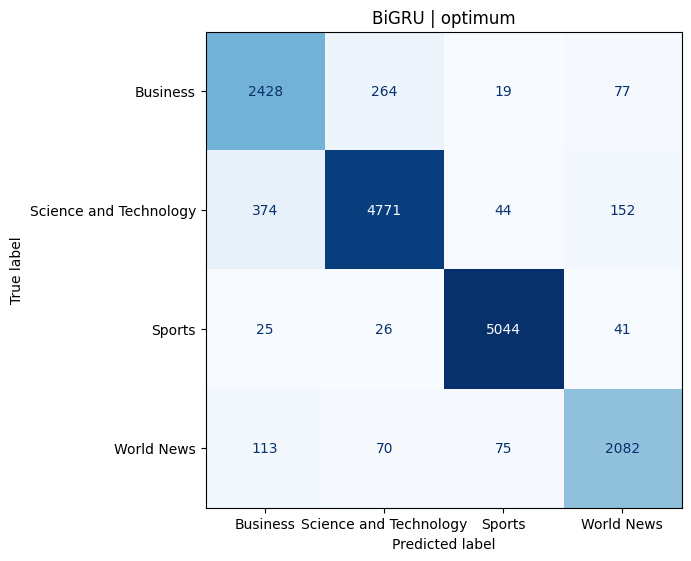

Running BiLSTM on optimum preprocessing
Epoch 1/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8003 - loss: 0.5644
Epoch 1: val_loss improved from None to 0.26860, saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiLSTM_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiLSTM_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 59s 160ms/step - accuracy: 0.8593 - loss: 0.4289 - val_accuracy: 0.9087 - val_loss: 0.2686 - learning_rate: 0.0010
Epoch 2/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8911 - loss: 0.3442
Epoch 2: val_loss improved from 0.26860 to 0.26468, saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiLSTM_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\SKIPGRAM_optimum_BiLSTM_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.8934 - loss: 0.3384 - v

,precision,recall,f1-score,support
Business,0.811321,0.879125,0.843863,2788.000000
Science and Technology,0.933712,0.891406,0.912069,5341.000000
Sports,0.976564,0.981698,0.979124,5136.000000
World News,0.891904,0.885043,0.888460,2340.000000
accuracy,0.917975,0.917975,0.917975,0.917975
macro avg,0.903375,0.909318,0.905879,15605.000000
weighted avg,0.919680,0.917975,0.918413,15605.000000


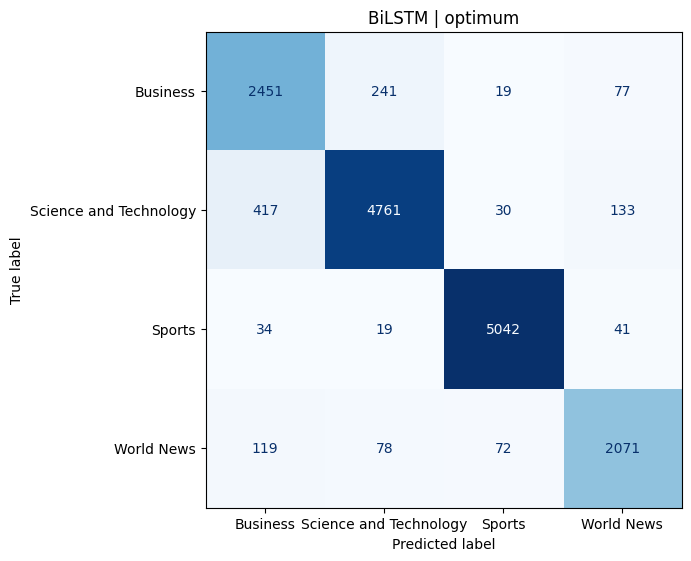

In [36]:
sequence_runs_optimum = {}

for model_name in ["SimpleRNN", "GRU", "LSTM", "BiSimpleRNN", "BiGRU", "BiLSTM"]:
    print("=" * 80)
    print(f"Running {model_name} on optimum preprocessing")
    sequence_runs_optimum[model_name] = run_sequence_model(
        prepared_optimum,
        model_name=model_name,
        units=128,
        dropout_rate=0.3,
        batch_size=256,
        epochs=12
    )

## Full long-running cell: run the six sequence models on all three preprocessing variants

Because preprocessing files, Skip-gram inputs, and model checkpoints are cached, rerunning this section will reuse saved artifacts whenever they already exist. Set `FORCE_REBUILD_SKIPGRAM=True` or `FORCE_RETRAIN=True` only when you intentionally want to rebuild them.


Running SimpleRNN on none
Epoch 1/12
347/349 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5650 - loss: 1.0086
Epoch 1: val_loss improved from None to 0.81853, saving model to project_cache\checkpoints\SKIPGRAM_none_SimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_none_SimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.6402 - loss: 0.9127 - val_accuracy: 0.6948 - val_loss: 0.8185 - learning_rate: 0.0010
Epoch 2/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5882 - loss: 1.0206
Epoch 2: val_loss did not improve from 0.81853
349/349 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.4487 - loss: 1.1984 - val_accuracy: 0.4021 - val_loss: 1.3360 - learning_rate: 0.0010
Epoch 3/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3122 - loss: 1.3403
Epoch 3: val_loss did not improve from 0.81853
349/349 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 

,precision,recall,f1-score,support
Business,0.410528,0.875538,0.558965,2788.000000
Science and Technology,0.879253,0.343569,0.494076,5341.000000
Sports,0.916118,0.920755,0.918431,5136.000000
World News,0.762656,0.785470,0.773895,2340.000000
accuracy,0.694841,0.694841,0.694841,0.694841
macro avg,0.742138,0.731333,0.686342,15605.000000
weighted avg,0.790159,0.694841,0.687295,15605.000000


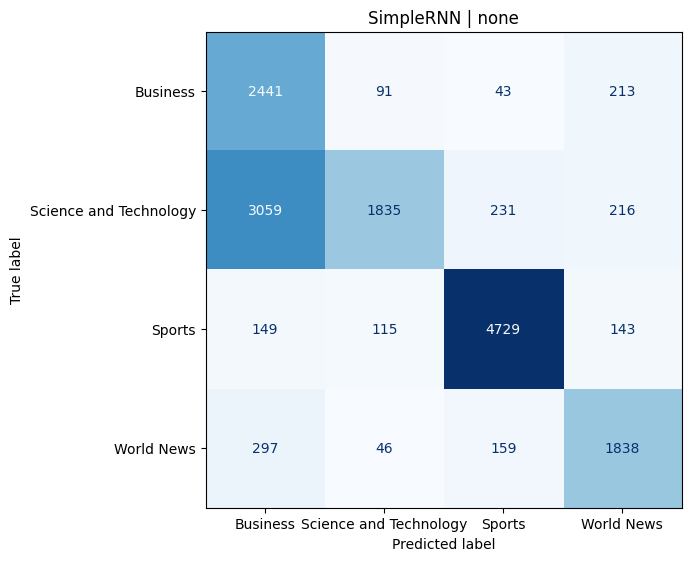

Running GRU on none
Epoch 1/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5227 - loss: 0.9893
Epoch 1: val_loss improved from None to 0.35346, saving model to project_cache\checkpoints\SKIPGRAM_none_GRU_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_none_GRU_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 38s 103ms/step - accuracy: 0.7146 - loss: 0.6954 - val_accuracy: 0.8823 - val_loss: 0.3535 - learning_rate: 0.0010
Epoch 2/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8669 - loss: 0.4221
Epoch 2: val_loss improved from 0.35346 to 0.33261, saving model to project_cache\checkpoints\SKIPGRAM_none_GRU_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\SKIPGRAM_none_GRU_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 37s 107ms/step - accuracy: 0.8680 - loss: 0.4172 - val_accuracy: 0.8855 - val_loss: 0.3326 - learn

,precision,recall,f1-score,support
Business,0.809524,0.847561,0.828106,2788.000000
Science and Technology,0.910196,0.897585,0.903846,5341.000000
Sports,0.972316,0.957360,0.964780,5136.000000
World News,0.861981,0.870085,0.866014,2340.000000
accuracy,0.904197,0.904197,0.904197,0.904197
macro avg,0.888504,0.893148,0.890687,15605.000000
weighted avg,0.905425,0.904197,0.904696,15605.000000


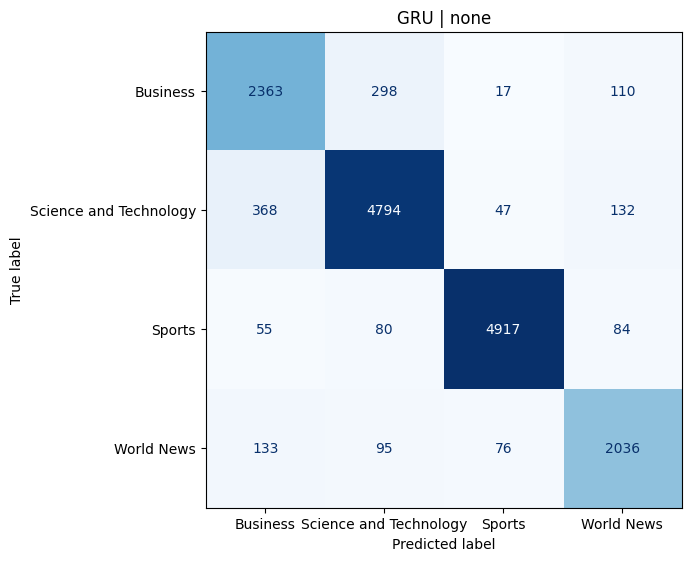

Running LSTM on none
Epoch 1/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6881 - loss: 0.7999
Epoch 1: val_loss improved from None to 0.37871, saving model to project_cache\checkpoints\SKIPGRAM_none_LSTM_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_none_LSTM_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 54s 149ms/step - accuracy: 0.7875 - loss: 0.6125 - val_accuracy: 0.8756 - val_loss: 0.3787 - learning_rate: 0.0010
Epoch 2/12
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8478 - loss: 0.4682
Epoch 2: val_loss improved from 0.37871 to 0.34508, saving model to project_cache\checkpoints\SKIPGRAM_none_LSTM_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\SKIPGRAM_none_LSTM_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 83s 238ms/step - accuracy: 0.8529 - loss: 0.4570 - val_accuracy: 0.8833 - val_loss: 0.3451 

,precision,recall,f1-score,support
Business,0.782693,0.869440,0.823789,2788.000000
Science and Technology,0.927579,0.875304,0.900684,5341.000000
Sports,0.964244,0.966121,0.965182,5136.000000
World News,0.874677,0.867949,0.871300,2340.000000
accuracy,0.903044,0.903044,0.903044,0.903044
macro avg,0.887298,0.894704,0.890239,15605.000000
weighted avg,0.905828,0.903044,0.903768,15605.000000


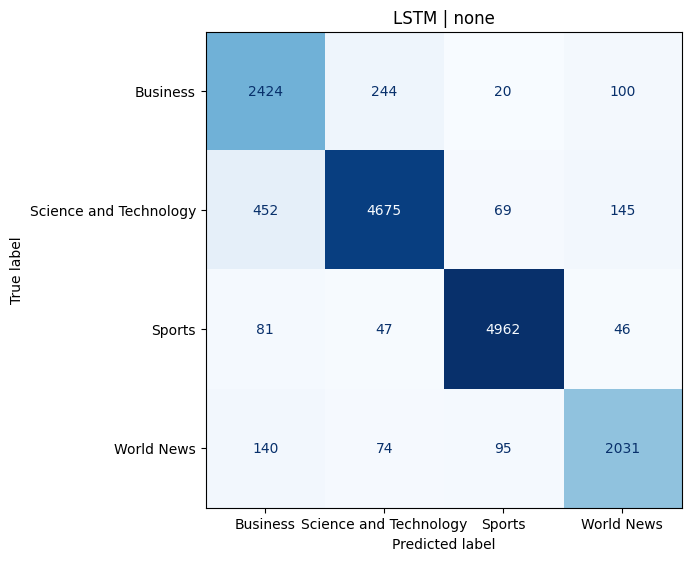

Running BiSimpleRNN on none
Epoch 1/12
348/349 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5773 - loss: 1.0198
Epoch 1: val_loss improved from None to 0.46602, saving model to project_cache\checkpoints\SKIPGRAM_none_BiSimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_none_BiSimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 64s 145ms/step - accuracy: 0.6937 - loss: 0.8271 - val_accuracy: 0.8458 - val_loss: 0.4660 - learning_rate: 0.0010
Epoch 2/12
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8033 - loss: 0.6068
Epoch 2: val_loss improved from 0.46602 to 0.43043, saving model to project_cache\checkpoints\SKIPGRAM_none_BiSimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\SKIPGRAM_none_BiSimpleRNN_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 48s 137ms/step - accuracy: 0.8048 - loss: 0.6028 - val_a

,precision,recall,f1-score,support
Business,0.750083,0.808465,0.778181,2788.000000
Science and Technology,0.887028,0.862947,0.874822,5341.000000
Sports,0.946602,0.949182,0.947890,5136.000000
World News,0.847826,0.816667,0.831955,2340.000000
accuracy,0.874656,0.874656,0.874656,0.874656
macro avg,0.857885,0.859315,0.858212,15605.000000
weighted avg,0.876290,0.874656,0.875177,15605.000000


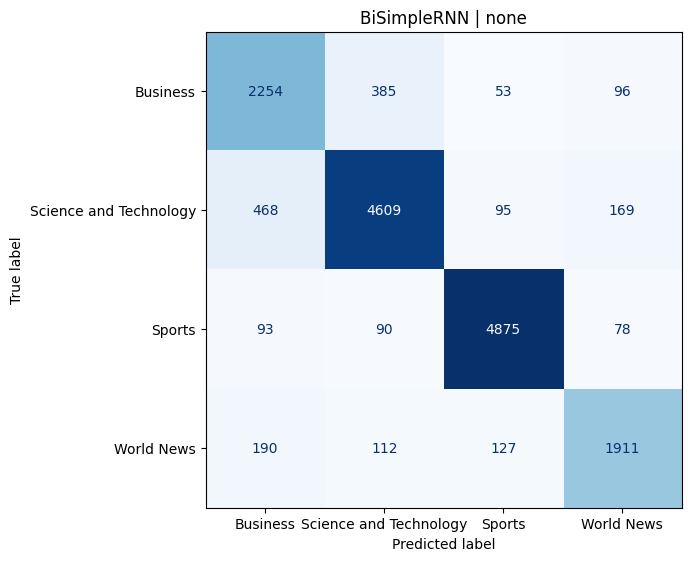

Running BiGRU on none
Epoch 1/12
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5519 - loss: 0.9647
Epoch 1: val_loss improved from None to 0.34823, saving model to project_cache\checkpoints\SKIPGRAM_none_BiGRU_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 1: finished saving model to project_cache\checkpoints\SKIPGRAM_none_BiGRU_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 70s 193ms/step - accuracy: 0.7314 - loss: 0.6772 - val_accuracy: 0.8834 - val_loss: 0.3482 - learning_rate: 0.0010
Epoch 2/12
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.8626 - loss: 0.4269
Epoch 2: val_loss improved from 0.34823 to 0.32725, saving model to project_cache\checkpoints\SKIPGRAM_none_BiGRU_u128_d0.3_bs256_ep12_seed42.weights.h5

Epoch 2: finished saving model to project_cache\checkpoints\SKIPGRAM_none_BiGRU_u128_d0.3_bs256_ep12_seed42.weights.h5
349/349 ━━━━━━━━━━━━━━━━━━━━ 104s 298ms/step - accuracy: 0.8668 - loss: 0.4185 - val_accuracy: 0.8886 - val_loss: 0

In [ ]:
sequence_runs_all = {}

for preprocessing_name in ["none", "extreme", "optimum"]:
    prepared_data = prepare_skipgram_inputs(
        preprocessing_name,
        train_versions[preprocessing_name],
        train_df["News Topic"],
        max_vocab=50000,
        max_len=60
    )

    for model_name in ["SimpleRNN", "GRU", "LSTM", "BiSimpleRNN", "BiGRU", "BiLSTM"]:
        print("=" * 80)
        print(f"Running {model_name} on {preprocessing_name}")
        sequence_runs_all[(preprocessing_name, model_name)] = run_sequence_model(
            prepared_data,
            model_name=model_name,
            units=128,
            dropout_rate=0.3,
            batch_size=256,
            epochs=12
        )

## Experiment results table

In [ ]:
results_df = pd.DataFrame(EXPERIMENT_LOG)
results_df.sort_values(["representation", "macro_f1"], ascending=[True, False])

## Experiment comparison plot

In [ ]:
if len(EXPERIMENT_LOG) > 0:
    results_plot_df = pd.DataFrame(EXPERIMENT_LOG).sort_values("macro_f1", ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(results_plot_df["model"] + " | " + results_plot_df["preprocessing"], results_plot_df["macro_f1"])
    plt.title("Validation macro F1 across experiments")
    plt.xlabel("Experiment")
    plt.ylabel("Macro F1")
    plt.xticks(rotation=75, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

    display(results_plot_df)

## Final test evaluation

Do this only after you finish manual tuning on the validation split.

The recommended process is:
1. choose the best configuration by validation macro F1
2. rebuild the chosen preprocessing on the full training set
3. retrain the chosen model on the full training set
4. transform the untouched test set once
5. report test accuracy, macro F1, confusion matrix, and classification report

## Final test evaluation helper

In [ ]:
def final_test_evaluation(best_preprocessing_name, best_vectorizer_params=None, best_model_params=None):
    if best_vectorizer_params is None:
        best_vectorizer_params = {"max_features": 40000, "ngram_range": (1, 2), "min_df": 3, "max_df": 0.95}
    if best_model_params is None:
        best_model_params = {"C": 3.0, "class_weight": "balanced"}

    X_train_full = train_versions[best_preprocessing_name]
    X_test_final = test_versions[best_preprocessing_name]
    y_train_full = train_df[TARGET_COLUMN]
    y_test_final = test_df[TARGET_COLUMN]

    vectorizer = TfidfVectorizer(
        max_features=best_vectorizer_params["max_features"],
        ngram_range=best_vectorizer_params["ngram_range"],
        min_df=best_vectorizer_params["min_df"],
        max_df=best_vectorizer_params["max_df"],
        sublinear_tf=True
    )

    X_train_full_tfidf = vectorizer.fit_transform(X_train_full)
    X_test_final_tfidf = vectorizer.transform(X_test_final)

    model = LogisticRegression(
        C=best_model_params["C"],
        max_iter=1500,
        class_weight=best_model_params["class_weight"]
    )
    model.fit(X_train_full_tfidf, y_train_full)
    test_pred = model.predict(X_test_final_tfidf)

    metrics, report_df = evaluate_predictions(y_test_final, test_pred, label_encoder.classes_)
    print(metrics)
    display(report_df)
    show_confusion(y_test_final, test_pred, label_encoder.classes_, f"Final test | Logistic Regression | {best_preprocessing_name}")
    return model, vectorizer, metrics, report_df

## Example final test evaluation cell

In [ ]:
final_model, final_vectorizer, final_metrics, final_report = final_test_evaluation(
    best_preprocessing_name="optimum",
    best_vectorizer_params={"max_features": 40000, "ngram_range": (1, 2), "min_df": 3, "max_df": 0.95},
    best_model_params={"C": 3.0, "class_weight": "balanced"}
)

## Report outline aligned to the PDF

1. Abstract
   - one paragraph with dataset, preprocessing variants, representations, models, and best result

2. Introduction
   - task definition
   - why multi-class news classification matters
   - short summary of the assigned dataset

3. Methodology
   - Dataset
   - EDA findings
   - Preprocessing
   - TF-IDF
   - Skip-gram
   - Model architectures
   - Hyperparameter tuning decisions

4. Results
   - table of all experiments
   - best and worst settings
   - confusion matrices
   - macro F1 comparison
   - discussion of why some preprocessings helped or hurt

5. Conclusion
   - main takeaways
   - limitations
   - future work

6. References
   - libraries
   - papers
   - tools
   - dataset/project PDF

## Report checklist table

In [ ]:
report_checklist = pd.DataFrame({
    "section": [
        "Abstract",
        "Introduction",
        "Dataset and EDA",
        "Preprocessing",
        "Word Representations",
        "Models",
        "Hyperparameter Tuning",
        "Results",
        "Best vs Worst Comparison",
        "Conclusion",
        "References"
    ],
    "what_to_include": [
        "overall approach, techniques, best result",
        "task motivation and dataset summary",
        "label distribution, duplicates, artifacts, word clouds, plots",
        "no/extreme/optimum preprocessing and why",
        "TF-IDF and Skip-gram implementation details",
        "ML, DNN, RNN, GRU, LSTM, bidirectional variants",
        "manual tuning choices and reasons",
        "accuracy, macro F1, confusion matrix, classification report",
        "why the best worked and why the worst failed",
        "main findings, limitations, future work",
        "IEEE-style citations for tools, libraries, papers, dataset PDF"
    ]
})
report_checklist

## Viva preparation points

Be ready to explain:
- why the train/test split was not changed
- why macro F1 matters here
- why you created exactly three preprocessing variants
- why you chose the optimum preprocessing decisions from EDA
- why a specific TF-IDF + ML model was chosen
- how Skip-gram embeddings were trained
- why one recurrent model performed better than another
- what the confusion matrix tells you about class confusion
- how class imbalance and duplicates affected the results